# 📊 Benchmark Phase 1 — MaroTrade Intelligence v4
### Pipeline 100% data-driven · Reproductible · Format PFE

> **Le score ML (data-driven) détermine le classement.
> Les 7 dimensions sont une lecture métier post-hoc pour l'explicabilité PME,
> pas la cible d'entraînement.**

| Paramètre | Valeur |
|---|---|
| **Source** | `data/raw/comtrade_ag2_full.csv` + accords/WB/OCDE/Trends |
| **Périmètre** | ~18 pays accords · ~85 produits AG2 · 2018–2024 |
| **Filtres** | value ≥ 100K USD · couple ≥ 500K cumulé & ≥ 3 ans |
| **Cible** | `log_return = log(V_{t+1}/V_t) × 100`, clip[-100, 100] |
| **Split** | Train ≤2021 · Val 2022-23 · Test 2024 |
| **CV** | Walk-forward par année — aucune fuite temporelle |
| **Sélection best model** | **Spearman val groupé** par (hs_code, year) |
| **INTERDIT** | Entraîner sur score_7D, 60/40 ou tout barème |

## Imports & Seeds

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
import scipy.stats as stats
from scipy.stats import spearmanr
import json
import os
import time

# ── Seeds ─────────────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── Style publication ─────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FA',
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    12,
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

COLORS = {
    'Ridge':    '#534AB7',
    'XGBoost':  '#1D9E75',
    'LightGBM': '#378ADD',
    'CatBoost': '#E24B4A',
}

FEAT_LABELS = {
    'log_value_usd':      'log(Valeur export)',
    'log_lag1':           'log(Export N-1)',
    'log_ma3':            'log(Moy. mobile 3 ans)',
    'std3':               'Volatilité 3 ans',
    'growth_lag1':        'Croissance lag1 (%)',
    'log_return_lag1':    'Log-return lag1',
    'price_usd_kg':       'Prix USD/kg',
    'market_share':       'Part de marché',
    'cagr_3y':            'CAGR 3 ans (feature)',
    'accord_score':       'Score accord (ALE/PREF/NPF)',
    'droits':             'Droits de douane (%)',
    'wb_gdp_per_capita':  'PIB/habitant (WB)',
    'wb_imports_pct_gdp': 'Imports % PIB (WB)',
    'wb_available':       'WB disponible (flag)',
    'ocde_risk_score':    'Score risque OCDE',
    'distance_km':        'Distance Maroc→pays (km)',
    'trend_score':        'Score Google Trends',
}

# ── Chemins ───────────────────────────────────────────────────────────────────
DATA_DIR     = '../data/raw'
FIGURES_DIR  = '../figures'
ARTIFACTS_DIR= '../artifacts'

os.makedirs(FIGURES_DIR,   exist_ok=True)
os.makedirs(ARTIFACTS_DIR, exist_ok=True)

print('✅ Imports OK')
print(f'   NumPy   : {np.__version__}')
print(f'   Pandas  : {pd.__version__}')
print(f'   Dossiers créés : {FIGURES_DIR} · {ARTIFACTS_DIR}')

✅ Imports OK
   NumPy   : 2.4.3
   Pandas  : 2.3.3
   Dossiers créés : ../figures · ../artifacts


 ## Chargement des données brutes

In [2]:
# ── Chargement des fichiers sources ──────────────────────────────────────────
df_train = pd.read_csv(f'{DATA_DIR}/ml_train.csv')
df_val   = pd.read_csv(f'{DATA_DIR}/ml_val.csv')
df_test  = pd.read_csv(f'{DATA_DIR}/ml_test.csv')
df_acc   = pd.read_csv(f'{DATA_DIR}/accords_maroc.csv',       index_col=0)
df_wb    = pd.read_csv(f'{DATA_DIR}/worldbank_indicators.csv', index_col=0)
df_ocde  = pd.read_csv(f'{DATA_DIR}/ocde_risk.csv',            index_col=0)

with open(f'{DATA_DIR}/google_trends.json') as f:
    trends_raw = json.load(f)

# ── Vue d'ensemble ────────────────────────────────────────────────────────────
df_raw = pd.concat([df_train, df_val, df_test], ignore_index=True)

print('Fichiers chargés')
print(f'\n── Comtrade brut ──')
print(f'   Lignes    : {len(df_raw):,}')
print(f'   Colonnes  : {list(df_raw.columns)}')
print(f'   Années    : {sorted(df_raw["year"].unique())}')
print(f'   HS codes  : {df_raw["hs_code"].nunique()}')
print(f'   Pays      : {df_raw["partner_code"].nunique()}')
print(f'   partner_code dtype  : {df_raw["partner_code"].dtype}')
print(f'   partner_code sample : {list(df_raw["partner_code"].unique()[:6])}')

print(f'\n── Accords Maroc ──')
print(f'   Pays   : {len(df_acc)}')
print(f'   Index  : {list(df_acc.index[:5])}')
print(f'   Cols   : {list(df_acc.columns)}')

print(f'\n── World Bank ──')
print(f'   Pays   : {len(df_wb)}')
print(f'   Cols   : {list(df_wb.columns)}')

print(f'\n── OCDE Risk ──')
print(f'   Pays   : {len(df_ocde)}')
print(f'   Cols   : {list(df_ocde.columns)}')

print(f'\n── Google Trends ──')
print(f'   Produits : {list(trends_raw.keys())}')
geo_sample = list(list(trends_raw.values())[0].keys())
print(f'   Pays     : {geo_sample}')

print(f'\n── log_return stats (brut) ──')
lr = df_raw['log_return'].dropna()
print(f'   n    : {len(lr):,}')
print(f'   mean : {lr.mean():.2f}%')
print(f'   std  : {lr.std():.2f}%')
print(f'   min  : {lr.min():.2f}%')
print(f'   max  : {lr.max():.2f}%')

Fichiers chargés



── Comtrade brut ──
   Lignes    : 30,193
   Colonnes  : ['hs_code', 'year', 'partner_code', 'hs_desc', 'partner_name', 'value_usd', 'weight_kg', 'price_usd_kg', 'value_next', 'log_return', 'target_year', 'lag1', 'lag2', 'lag3', 'ma3', 'std3', 'growth_lag1', 'log_return_lag1', 'price_lag1']
   Années    : [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
   HS codes  : 93
   Pays      : 187
   partner_code dtype  : int64
   partner_code sample : [np.int64(24), np.int64(251), np.int64(324), np.int64(392), np.int64(466), np.int64(478)]

── Accords Maroc ──
   Pays   : 20
   Index  : ['FRA', 'DEU', 'USA', 'ESP', 'ITA']
   Cols   : ['accord', 'droits', 'type']

── World Bank ──
   Pays   : 20
   Cols   : ['name', 'gdp_per_capita', 'gdp_per_capita_year', 'imports_pct_gdp', 'imports_pct_gdp_year', 'trade_pct_gdp', 'trade_pct_gdp_year']

── OCDE Risk ──
   Pays   : 20
   Cols   : ['category', 'sco

## Mappings & Constantes
Définit tous les mappings nécessaires pour relier les 3 formats de codes pays (UN numérique, ISO3, ISO2) et les clés Google Trends. Vérifie aussi la couverture réelle des pays accords dans le dataset.
Ce qu'on veut confirmer :

        Combien des 20 pays accords sont présents dans le dataset
        Si tous les pays df_acc sont mappables vers des codes UN
        Quelles colonnes numériques sont disponibles dans df_wb

In [3]:
# ── Mapping ISO3 → code numérique UN ─────────────────────────────────────────
ISO3_TO_UN = {
    'FRA': 251, 'DEU': 276, 'USA': 842, 'ESP': 724, 'ITA': 380,
    'NLD': 528, 'BEL':  56, 'GBR': 826, 'CAN': 124, 'JPN': 392,
    'SAU': 682, 'ARE': 784, 'QAT': 634, 'KWT': 414, 'CHN': 156,
    'KOR': 410, 'SGP': 702, 'AUS':  36, 'NOR': 578, 'CHE': 756,
}
UN_TO_ISO3  = {v: k for k, v in ISO3_TO_UN.items()}
ISO3_TO_ISO2 = {
    'FRA': 'FR', 'DEU': 'DE', 'USA': 'US', 'ESP': 'ES', 'ITA': 'IT',
    'NLD': 'NL', 'BEL': 'BE', 'GBR': 'GB', 'CAN': 'CA', 'JPN': 'JP',
    'SAU': 'SA', 'ARE': 'AE', 'QAT': 'QA', 'KWT': 'KW', 'CHN': 'CN',
    'KOR': 'KR', 'SGP': 'SG', 'AUS': 'AU', 'NOR': 'NO', 'CHE': 'CH',
}

# ── Distance Maroc (Casablanca) → pays partenaires (km) ──────────────────────
DISTANCE_KM = {
    251: 2400, 276: 2900, 842: 7200, 724:  750, 380: 2200,
    528: 2700,  56: 2800, 826: 2600, 124: 7800, 392: 11000,
    682: 4500, 784: 5800, 634: 5200, 414: 5100, 156:  9500,
    410: 10800, 702: 10800,  36: 16000, 578: 3800, 756: 2600,
}

# ── Pays avec accords (codes UN) ──────────────────────────────────────────────
PAYS_ACCORDS_UN = set(ISO3_TO_UN.values())

# ── Mapping HS AG2 → clés Google Trends ──────────────────────────────────────
HS_TO_TRENDS = {
    '15': ['151590', '150910'],
    '9':  ['09102010', '090920'],
    '16': ['160413'],
    '8':  ['080410', '080521'],
    '57': ['570110'],
    '69': ['691010'],
    '7':  ['070200'],
}

# ── Vérifications ─────────────────────────────────────────────────────────────
pays_dans_data = set(df_raw['partner_code'].unique())
pays_avec_acc  = PAYS_ACCORDS_UN & pays_dans_data
pays_manquants = PAYS_ACCORDS_UN - pays_dans_data

print('✅ Mappings définis')
print(f'\n── Couverture pays accords ──')
print(f'   Pays accords définis      : {len(PAYS_ACCORDS_UN)}')
print(f'   Présents dans le dataset  : {len(pays_avec_acc)}')
print(f'   Absents du dataset        : {len(pays_manquants)}')
if pays_manquants:
    absents_iso3 = [UN_TO_ISO3[p] for p in pays_manquants]
    print(f'   ISO3 absents              : {absents_iso3}')

print(f'\n── Cohérence accords ──')
acc_index_un = {ISO3_TO_UN[i] for i in df_acc.index if i in ISO3_TO_UN}
print(f'   df_acc mappable vers UN   : {len(acc_index_un)} pays')
print(f'   Exemple accord ──')
print(df_acc.head(3))

print(f'\n── Cohérence WB ──')
wb_index_un = {ISO3_TO_UN[i] for i in df_wb.index if i in ISO3_TO_UN}
print(f'   df_wb mappable vers UN    : {len(wb_index_un)} pays')
print(f'   Colonnes numériques       : {[c for c in df_wb.columns if "year" not in c and c != "name"]}')

✅ Mappings définis

── Couverture pays accords ──
   Pays accords définis      : 20
   Présents dans le dataset  : 18
   Absents du dataset        : 2
   ISO3 absents              : ['NOR', 'CHE']

── Cohérence accords ──
   df_acc mappable vers UN   : 20 pays
   Exemple accord ──
                    accord  droits type
FRA  Accord association UE     0.0  ALE
DEU  Accord association UE     0.0  ALE
USA   Accord libre-échange     0.0  ALE

── Cohérence WB ──
   df_wb mappable vers UN    : 20 pays
   Colonnes numériques       : ['gdp_per_capita', 'imports_pct_gdp', 'trade_pct_gdp']


---
## Filtres & Périmètre

In [4]:
# ── Étape 1 : Supprimer leakage ───────────────────────────────────────────────
COLS_LEAKAGE = ['value_next', 'price_lag1']
df = df_raw.drop(columns=[c for c in COLS_LEAKAGE if c in df_raw.columns])
print(f'✅ Leakage supprimé : {COLS_LEAKAGE}')

# ── Étape 2 : Filtre pays avec accords ───────────────────────────────────────
n0 = len(df)
df = df[df['partner_code'].isin(PAYS_ACCORDS_UN)].copy()
n1 = len(df)
print(f'\n── Filtre pays accords ──')
print(f'   Avant : {n0:,}  →  Après : {n1:,}  (−{n0-n1:,})')
print(f'   Pays restants : {df["partner_code"].nunique()}')

# ── Étape 3 : Filtre value_usd ≥ 100K ────────────────────────────────────────
n1b = len(df)
df  = df[df['value_usd'] >= 100_000].copy()
n2  = len(df)
print(f'\n── Filtre value_usd ≥ 100K USD ──')
print(f'   Avant : {n1b:,}  →  Après : {n2:,}  (−{n1b-n2:,})')
pct_bruit = (n1b - n2) / n1b * 100
print(f'   Lignes bruit supprimées : {pct_bruit:.1f}%')

# ── Étape 4 : Filtre couple ≥ 500K cumulé ET ≥ 3 ans ─────────────────────────
cum = df.groupby(['hs_code', 'partner_code'])['value_usd'].sum()
yrs = df.groupby(['hs_code', 'partner_code'])['year'].nunique()

couples_ok = set(zip(
    cum[cum >= 500_000].reset_index()['hs_code'],
    cum[cum >= 500_000].reset_index()['partner_code']
)) & set(zip(
    yrs[yrs >= 3].reset_index()['hs_code'],
    yrs[yrs >= 3].reset_index()['partner_code']
))

n2b = len(df)
df  = df[df.apply(
    lambda r: (r['hs_code'], r['partner_code']) in couples_ok, axis=1
)].copy()
n3  = len(df)
print(f'\n── Filtre couple ≥ 500K cumulé & ≥ 3 ans ──')
print(f'   Avant : {n2b:,}  →  Après : {n3:,}  (−{n2b-n3:,})')
print(f'   Couples valides : {len(couples_ok)}')

# ── Étape 5 : Clip log_return [-100, 100] ────────────────────────────────────
df['log_return'] = df['log_return'].clip(-100, 100)
lr_after = df['log_return'].dropna()
print(f'\n── Clip log_return [-100, 100] ──')
print(f'   std avant : 78.49%')
print(f'   std après : {lr_after.std():.2f}%')

# ── Étape 6 : Supprimer lags incomplets ──────────────────────────────────────
n3b = len(df)
df  = df.dropna(subset=['lag1', 'lag2', 'lag3', 'log_return']).copy()
n4  = len(df)
print(f'\n── Drop lags incomplets (lag1/2/3 + log_return) ──')
print(f'   Avant : {n3b:,}  →  Après : {n4:,}  (−{n3b-n4:,})')

# ── Résumé ────────────────────────────────────────────────────────────────────
print(f'\n{"="*45}')
print(f'  DATASET FINAL')
print(f'{"="*45}')
print(f'  Lignes    : {len(df):,}')
print(f'  HS codes  : {df["hs_code"].nunique()}')
print(f'  Pays      : {df["partner_code"].nunique()}')
print(f'  Années    : {sorted(df["year"].unique())}')
print(f'  log_return mean : {df["log_return"].mean():.2f}%')
print(f'  log_return std  : {df["log_return"].std():.2f}%')
print(f'{"="*45}')

✅ Leakage supprimé : ['value_next', 'price_lag1']

── Filtre pays accords ──
   Avant : 30,193  →  Après : 8,322  (−21,871)
   Pays restants : 18

── Filtre value_usd ≥ 100K USD ──
   Avant : 8,322  →  Après : 5,574  (−2,748)
   Lignes bruit supprimées : 33.0%

── Filtre couple ≥ 500K cumulé & ≥ 3 ans ──
   Avant : 5,574  →  Après : 5,295  (−279)
   Couples valides : 686

── Clip log_return [-100, 100] ──
   std avant : 78.49%
   std après : 53.38%

── Drop lags incomplets (lag1/2/3 + log_return) ──
   Avant : 5,295  →  Après : 3,525  (−1,770)

  DATASET FINAL
  Lignes    : 3,525
  HS codes  : 82
  Pays      : 18
  Années    : [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]
  log_return mean : 13.80%
  log_return std  : 55.78%


##  Feature Engineering

In [5]:
# ── Copie de travail ──────────────────────────────────────────────────────────
df_fe = df.copy()

# ── Log-transforms (réduire l'effet des valeurs extrêmes) ────────────────────
df_fe['log_value_usd'] = np.log1p(df_fe['value_usd'])
df_fe['log_lag1']      = np.log1p(df_fe['lag1'].clip(lower=0))
df_fe['log_ma3']       = np.log1p(df_fe['ma3'].clip(lower=0))

# ── Part de marché (position relative dans le produit × année) ───────────────
total_hs_yr            = df_fe.groupby(['hs_code', 'year'])['value_usd'].transform('sum')
df_fe['market_share']  = df_fe['value_usd'] / total_hs_yr.replace(0, np.nan)

# ── CAGR 3 ans (feature temporelle, pas cible) ────────────────────────────────
df_fe['cagr_3y'] = np.where(
    (df_fe['lag3'] > 0) & (df_fe['value_usd'] > 0),
    (np.power(
        df_fe['value_usd'] / df_fe['lag3'].replace(0, np.nan),
        1/3
    ) - 1) * 100,
    np.nan
)

# ── Enrichissement Accords Maroc ──────────────────────────────────────────────
type_map   = {'ALE': 1.0, 'PREF': 0.6, 'NPF': 0.3}
acc_score  = {ISO3_TO_UN[i]: type_map.get(r['type'], 0.3)
              for i, r in df_acc.iterrows() if i in ISO3_TO_UN}
acc_droits = {ISO3_TO_UN[i]: float(r['droits'])
              for i, r in df_acc.iterrows() if i in ISO3_TO_UN}

df_fe['accord_score'] = df_fe['partner_code'].map(acc_score)
df_fe['droits']       = df_fe['partner_code'].map(acc_droits)

# ── Enrichissement World Bank ─────────────────────────────────────────────────
wb_gdp = {ISO3_TO_UN[i]: float(r['gdp_per_capita'])
          for i, r in df_wb.iterrows()
          if i in ISO3_TO_UN and pd.notna(r.get('gdp_per_capita'))}
wb_imp = {ISO3_TO_UN[i]: float(r['imports_pct_gdp'])
          for i, r in df_wb.iterrows()
          if i in ISO3_TO_UN and pd.notna(r.get('imports_pct_gdp'))}

df_fe['wb_gdp_per_capita']  = df_fe['partner_code'].map(wb_gdp)
df_fe['wb_imports_pct_gdp'] = df_fe['partner_code'].map(wb_imp)
df_fe['wb_available']       = df_fe['wb_gdp_per_capita'].notna().astype(int)

# ── Enrichissement OCDE ───────────────────────────────────────────────────────
ocde_sc = {ISO3_TO_UN[i]: float(r['score'])
           for i, r in df_ocde.iterrows()
           if i in ISO3_TO_UN and pd.notna(r.get('score'))}

df_fe['ocde_risk_score'] = df_fe['partner_code'].map(ocde_sc)

# ── Distance ─────────────────────────────────────────────────────────────────
df_fe['distance_km'] = df_fe['partner_code'].map(DISTANCE_KM)

# ── Google Trends ─────────────────────────────────────────────────────────────
def get_trend_score(row):
    ag2  = str(int(row['hs_code']))
    iso3 = UN_TO_ISO3.get(int(row['partner_code']))
    geo  = ISO3_TO_ISO2.get(iso3, '') if iso3 else ''
    for hs_key in HS_TO_TRENDS.get(ag2, []):
        if hs_key in trends_raw and geo in trends_raw[hs_key]:
            return float(trends_raw[hs_key][geo]['mean'])
    return 50.0  # valeur neutre si pas de données

df_fe['trend_score'] = df_fe.apply(get_trend_score, axis=1)

# ── Imputation médiane pour valeurs manquantes ────────────────────────────────
COLS_IMPUTE = [
    'wb_gdp_per_capita', 'wb_imports_pct_gdp',
    'ocde_risk_score', 'distance_km',
    'accord_score', 'droits',
    'cagr_3y', 'market_share'
]
for col in COLS_IMPUTE:
    med = df_fe[col].median()
    df_fe[col] = df_fe[col].fillna(med if pd.notna(med) else 0)

# ── Liste finale des features ─────────────────────────────────────────────────
FEATURES = [
    # Temporelles
    'log_value_usd', 'log_lag1', 'log_ma3', 'std3',
    'growth_lag1', 'log_return_lag1', 'price_usd_kg',
    'market_share', 'cagr_3y',
    # Accords
    'accord_score', 'droits',
    # World Bank
    'wb_gdp_per_capita', 'wb_imports_pct_gdp', 'wb_available',
    # Risque & Logistique
    'ocde_risk_score', 'distance_km',
    # Tendance
    'trend_score',
]
TARGET = 'log_return'

# ── Vérification ──────────────────────────────────────────────────────────────
print('✅ Feature engineering terminé')
print(f'\n── Features ({len(FEATURES)}) ──')
for f in FEATURES:
    n_miss = df_fe[f].isna().sum()
    flag   = ' ⚠️' if n_miss > 0 else ''
    print(f'   {f:<25} manquants={n_miss}{flag}')

print(f'\n── Vérification anti-leakage ──')
for col in ['value_next', 'price_lag1']:
    present = col in df_fe.columns
    print(f'   {col:<15} : {"⚠️  PRÉSENT" if present else "✅ absent"}')

print(f'\n── wb_available ──')
print(f'   Pays avec WB : {df_fe["wb_available"].sum()} / {len(df_fe)} lignes')

✅ Feature engineering terminé

── Features (17) ──
   log_value_usd             manquants=0
   log_lag1                  manquants=0
   log_ma3                   manquants=0
   std3                      manquants=0
   growth_lag1               manquants=0
   log_return_lag1           manquants=0
   price_usd_kg              manquants=0
   market_share              manquants=0
   cagr_3y                   manquants=0
   accord_score              manquants=0
   droits                    manquants=0
   wb_gdp_per_capita         manquants=0
   wb_imports_pct_gdp        manquants=0
   wb_available              manquants=0
   ocde_risk_score           manquants=0
   distance_km               manquants=0
   trend_score               manquants=0

── Vérification anti-leakage ──
   value_next      : ✅ absent
   price_lag1      : ✅ absent

── wb_available ──
   Pays avec WB : 3525 / 3525 lignes


## 6 Split temporel

In [6]:
# ── Split temporel strict ─────────────────────────────────────────────────────
# Les lignes year=N utilisent les features connues en N pour predire target_year=N+1.
latest_feature_year = int(df_fe['year'].max())
val_years = [latest_feature_year - 2, latest_feature_year - 1]

train = df_fe[df_fe['year'] < val_years[0]].copy()
val   = df_fe[df_fe['year'].isin(val_years)].copy()
test  = df_fe[df_fe['year'] == latest_feature_year].copy()

print('✅ Split temporel')
print(f'\n   Train (≤2021)    : {len(train):,} lignes | années {sorted(train["year"].unique())}')
print(f'   Val   (2022-23)  : {len(val):,} lignes | années {sorted(val["year"].unique())}')
print(f'   Test  (2024)     : {len(test):,} lignes | années {sorted(test["year"].unique())}')

# ── Préparation X / y ─────────────────────────────────────────────────────────
def prepare_xy(df_in, features, target, fit_scaler=None):
    """
    Prépare X et y depuis un DataFrame.
    - Impute les manquants par la médiane du df_in (train only si fit_scaler=None)
    - Applique RobustScaler (fit sur train, transform sur val/test)
    Retourne : X_scaled, y, hs_codes, years, scaler
    """
    from sklearn.preprocessing import RobustScaler

    d = df_in[features + [target, 'hs_code', 'year']].copy()

    # Imputation médiane — toujours sur les données courantes
    for col in features:
        d[col] = pd.to_numeric(d[col], errors='coerce')
        med    = d[col].median()
        d[col] = d[col].fillna(med if pd.notna(med) else 0)

    d = d.dropna(subset=[target])

    X         = d[features].values
    y         = d[target].values
    hs_codes  = d['hs_code'].values
    years     = d['year'].values

    if fit_scaler is None:
        # Train : fit + transform
        scaler = RobustScaler()
        X_sc   = scaler.fit_transform(X)
        return X_sc, y, hs_codes, years, scaler
    else:
        # Val / Test : transform uniquement
        X_sc = fit_scaler.transform(X)
        return X_sc, y, hs_codes, years, fit_scaler

# ── Appliquer ─────────────────────────────────────────────────────────────────
X_tr, y_tr, hs_tr, yr_tr, scaler = prepare_xy(train, FEATURES, TARGET)
X_v,  y_v,  hs_v,  yr_v,  _     = prepare_xy(val,   FEATURES, TARGET, scaler)
X_te, y_te, hs_te, yr_te, _     = prepare_xy(test,  FEATURES, TARGET, scaler)

print(f'\n── Shapes après scaling ──')
print(f'   X_tr : {X_tr.shape}  |  y_tr : {y_tr.shape}')
print(f'   X_v  : {X_v.shape}   |  y_v  : {y_v.shape}')
print(f'   X_te : {X_te.shape}  |  y_te : {y_te.shape}')

print(f'\n── y stats ──')
print(f'   y_tr  mean={y_tr.mean():.2f}%  std={y_tr.std():.2f}%')
print(f'   y_v   mean={y_v.mean():.2f}%   std={y_v.std():.2f}%')
print(f'   y_te  mean={y_te.mean():.2f}%  std={y_te.std():.2f}%')

print(f'\n── RobustScaler ──')
print(f'   Fitted sur train uniquement ✅')
print(f'   Transform appliqué sur val/test ✅')

✅ Split temporel

   Train (≤2021)    : 1,755 lignes | années [np.int64(2018), np.int64(2019), np.int64(2020)]
   Val   (2022-23)  : 1,191 lignes | années [np.int64(2021), np.int64(2022)]
   Test  (2024)     : 579 lignes | années [np.int64(2023)]



── Shapes après scaling ──
   X_tr : (1755, 17)  |  y_tr : (1755,)
   X_v  : (1191, 17)   |  y_v  : (1191,)
   X_te : (579, 17)  |  y_te : (579,)

── y stats ──
   y_tr  mean=1.00%  std=50.32%
   y_v   mean=2.34%   std=48.49%
   y_te  mean=76.22%  std=42.00%

── RobustScaler ──
   Fitted sur train uniquement ✅
   Transform appliqué sur val/test ✅


## 7 Fonction Spearman groupé & Baselines

In [7]:
from sklearn.metrics import mean_squared_error, r2_score

# ── Fonction Spearman groupé par (hs_code, year) ─────────────────────────────
def spearman_grouped(y_true, y_pred, hs_codes, years, min_group=3):
    """
    Calcule le Spearman moyen par groupe (hs_code, year).
    Pour chaque groupe : Spearman entre y_true et y_pred sur les pays.
    C'est la métrique pertinente pour le ranking PME.
    """
    df_tmp = pd.DataFrame({
        'y':  y_true,
        'yp': y_pred,
        'hs': hs_codes,
        'yr': years
    })
    corrs = []
    for (hs, yr), grp in df_tmp.groupby(['hs', 'yr']):
        if len(grp) >= min_group:
            sp = spearmanr(grp['y'], grp['yp']).correlation
            if not np.isnan(sp):
                corrs.append(sp)
    return float(np.mean(corrs)) if corrs else 0.0

def eval_model(y_true, y_pred, hs_codes, years, label=''):
    """Calcule RMSE, R², Spearman groupé."""
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    r2   = float(r2_score(y_true, y_pred))
    sp   = spearman_grouped(y_true, y_pred, hs_codes, years)
    if label:
        print(f'   {label:<18} RMSE={rmse:.3f}  R²={r2:.4f}  Spearman={sp:.4f}')
    return rmse, r2, sp

# ── Baselines ─────────────────────────────────────────────────────────────────
print('── Baselines (val set) ──')

# Naïf-0 : prédit toujours 0
y_naive0 = np.zeros(len(y_v))
rmse_n0, r2_n0, sp_n0 = eval_model(y_v, y_naive0, hs_v, yr_v, 'Naïf-0')

# Naïf-lag : prédit log_return_lag1
lag_idx       = FEATURES.index('log_return_lag1')
y_naive_lag   = X_v[:, lag_idx]
rmse_nl, r2_nl, sp_nl = eval_model(y_v, y_naive_lag, hs_v, yr_v, 'Naïf-lag')

# Volume-only : Ridge sur log_value_usd seul
from sklearn.linear_model import Ridge
vol_idx    = FEATURES.index('log_value_usd')
X_vol_tr   = X_tr[:, [vol_idx]]
X_vol_v    = X_v[:,  [vol_idx]]
vol_model  = Ridge(alpha=1.0)
vol_model.fit(X_vol_tr, y_tr)
y_vol_pred = vol_model.predict(X_vol_v)
rmse_vl, r2_vl, sp_vl = eval_model(y_v, y_vol_pred, hs_v, yr_v, 'Volume-only')

BASELINES = {
    'Naif-0':      {'val_rmse': rmse_n0, 'val_r2': r2_n0, 'val_spearman': sp_n0},
    'Naif-lag':    {'val_rmse': rmse_nl, 'val_r2': r2_nl, 'val_spearman': sp_nl},
    'Volume-only': {'val_rmse': rmse_vl, 'val_r2': r2_vl, 'val_spearman': sp_vl},
}

print(f'\n── Interprétation baselines ──')
print(f'   Un modèle ML doit dépasser Naïf-0 sur Spearman')
print(f'   Spearman Naïf-0 = {sp_n0:.4f} → seuil à battre')
print(f'   Spearman Volume = {sp_vl:.4f} → signal volume seul')

── Baselines (val set) ──
   Naïf-0             RMSE=48.546  R²=-0.0023  Spearman=0.0000
   Naïf-lag           RMSE=48.503  R²=-0.0006  Spearman=-0.0208


   Volume-only        RMSE=48.492  R²=-0.0001  Spearman=-0.0158

── Interprétation baselines ──
   Un modèle ML doit dépasser Naïf-0 sur Spearman
   Spearman Naïf-0 = 0.0000 → seuil à battre
   Spearman Volume = -0.0158 → signal volume seul


## 8 CV Walk-Forward & Benchmark

In [8]:
from sklearn.linear_model import Ridge
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# ── CV Walk-forward par année (sans fuite) ────────────────────────────────────
def cv_walkforward(model_class, model_params, df_data, features, target, min_train=200):
    """
    Pour chaque année t dans [2019, 2020, 2021] :
      - Train sur années < t
      - Val sur année t
      - Calcule Spearman groupé
    Retourne la moyenne des Spearman.
    """
    years_all = sorted(df_data['year'].unique())
    scores    = []

    for yr_val in years_all[1:]:  # skip 2018 (pas assez de train)
        tr = df_data[df_data['year'] <  yr_val]
        vl = df_data[df_data['year'] == yr_val]
        if len(tr) < min_train or len(vl) < 10:
            continue

        X_tr2, y_tr2, _, _,    sc2 = prepare_xy(tr, features, target)
        X_vl2, y_vl2, hs2, yr2, _  = prepare_xy(vl, features, target, sc2)

        m = model_class(**model_params)
        m.fit(X_tr2, y_tr2)
        yp2 = m.predict(X_vl2)

        sp2 = spearman_grouped(y_vl2, yp2, hs2, yr2)
        scores.append(sp2)

    mean_sp = float(np.mean(scores)) if scores else 0.0
    return mean_sp, scores

# ── Définition des modèles ────────────────────────────────────────────────────
MODEL_CONFIGS = {
    'Ridge': (Ridge, {
        'alpha': 1.0,
    }),
    'XGBoost': (XGBRegressor, {
        'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05,
        'subsample': 0.8, 'colsample_bytree': 0.8,
        'min_child_weight': 10, 'reg_alpha': 1.0, 'reg_lambda': 5.0,
        'random_state': RANDOM_STATE, 'verbosity': 0,
    }),
    'LightGBM': (LGBMRegressor, {
        'n_estimators': 300, 'max_depth': 3, 'learning_rate': 0.05,
        'num_leaves': 8, 'subsample': 0.8, 'colsample_bytree': 0.8,
        'min_child_samples': 30, 'reg_alpha': 1.0, 'reg_lambda': 5.0,
        'random_state': RANDOM_STATE, 'verbose': -1,
    }),
    'CatBoost': (CatBoostRegressor, {
        'iterations': 300, 'depth': 3, 'learning_rate': 0.05,
        'l2_leaf_reg': 10.0, 'min_data_in_leaf': 20,
        'random_seed': RANDOM_STATE, 'verbose': 0,
        'allow_writing_files': False,
    }),
}

# ── Benchmark ─────────────────────────────────────────────────────────────────
print('── Benchmark (train→val) ──')
print(f'{"Modèle":<12} {"CV-Sp":>8} {"Val RMSE":>10} {"Val R²":>9} {"Val Sp":>9} {"Test RMSE":>11} {"Test R²":>9} {"Test Sp":>9} {"t(s)":>6}')
print('─' * 90)

RESULTS      = {}
FITTED_MODELS = {}

for name, (model_class, params) in MODEL_CONFIGS.items():
    t0 = time.time()

    # CV walk-forward
    cv_sp, cv_scores = cv_walkforward(
        model_class, params, df_fe[df_fe['year'] <= 2021],
        FEATURES, TARGET
    )

    # Entraînement final sur train
    model = model_class(**params)
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    # Val
    yv_pred  = model.predict(X_v)
    val_rmse, val_r2, val_sp = eval_model(y_v, yv_pred, hs_v, yr_v)

    # Test
    yt_pred  = model.predict(X_te)
    te_rmse, te_r2, te_sp = eval_model(y_te, yt_pred, hs_te, yr_te)

    RESULTS[name] = {
        'cv_spearman':   cv_sp,
        'cv_scores':     cv_scores,
        'val_rmse':  val_rmse, 'val_r2':  val_r2,  'val_spearman':  val_sp,
        'test_rmse': te_rmse,  'test_r2': te_r2,   'test_spearman': te_sp,
        'time': elapsed,
        'y_pred_val':  yv_pred.tolist(),
        'y_pred_test': yt_pred.tolist(),
    }
    FITTED_MODELS[name] = model

    print(f'{name:<12} {cv_sp:>8.4f} {val_rmse:>10.3f} {val_r2:>9.4f} '
          f'{val_sp:>9.4f} {te_rmse:>11.3f} {te_r2:>9.4f} '
          f'{te_sp:>9.4f} {elapsed:>5.1f}s')

print('─' * 90)

# ── Sélection best model sur Spearman val ─────────────────────────────────────
BEST_MODEL = max(RESULTS, key=lambda k: RESULTS[k]['val_spearman'])
print(f'\n✅ Best model (Spearman val groupé) : {BEST_MODEL}')
print(f'   Spearman val = {RESULTS[BEST_MODEL]["val_spearman"]:.4f}')
print(f'   Val RMSE     = {RESULTS[BEST_MODEL]["val_rmse"]:.3f}')

── Benchmark (train→val) ──
Modèle          CV-Sp   Val RMSE    Val R²    Val Sp   Test RMSE   Test R²   Test Sp   t(s)
──────────────────────────────────────────────────────────────────────────────────────────


Ridge          0.0689     83.876   -1.9921    0.0855      86.874   -3.2784    0.1201   0.2s


XGBoost        0.1043     49.256   -0.0319    0.0801      86.495   -3.2411   -0.0116   0.8s


LightGBM       0.1059     48.613   -0.0051    0.1071      86.733   -3.2646   -0.0143   6.3s


CatBoost       0.1200     48.671   -0.0075    0.0961      86.409   -3.2327    0.0444   1.7s
──────────────────────────────────────────────────────────────────────────────────────────

✅ Best model (Spearman val groupé) : LightGBM
   Spearman val = 0.1071
   Val RMSE     = 48.613


## 9 - Bootstrap IC 95%

In [9]:
# ── Bootstrap IC 95% sur le best model ───────────────────────────────────────
N_BOOT = 1000
np.random.seed(RANDOM_STATE)

yp_best = np.array(RESULTS[BEST_MODEL]['y_pred_val'])

boot_rmse, boot_r2, boot_sp = [], [], []

for _ in range(N_BOOT):
    idx = np.random.choice(len(y_v), len(y_v), replace=True)
    boot_rmse.append(float(np.sqrt(mean_squared_error(y_v[idx], yp_best[idx]))))
    boot_r2.append(float(r2_score(y_v[idx], yp_best[idx])))
    boot_sp.append(spearman_grouped(y_v[idx], yp_best[idx], hs_v[idx], yr_v[idx]))

CI_RMSE = [float(np.percentile(boot_rmse, 2.5)), float(np.percentile(boot_rmse, 97.5))]
CI_R2   = [float(np.percentile(boot_r2,   2.5)), float(np.percentile(boot_r2,   97.5))]
CI_SP   = [float(np.percentile(boot_sp,   2.5)), float(np.percentile(boot_sp,   97.5))]

print(f'✅ Bootstrap terminé (n={N_BOOT})')
print(f'\n── IC 95% Bootstrap — {BEST_MODEL} ──')
print(f'   RMSE     : {RESULTS[BEST_MODEL]["val_rmse"]:.3f}  [{CI_RMSE[0]:.3f}, {CI_RMSE[1]:.3f}]')
print(f'   R²       : {RESULTS[BEST_MODEL]["val_r2"]:.4f}  [{CI_R2[0]:.4f}, {CI_R2[1]:.4f}]')
print(f'   Spearman : {RESULTS[BEST_MODEL]["val_spearman"]:.4f}  [{CI_SP[0]:.4f}, {CI_SP[1]:.4f}]')

print(f'\n── Interprétation ──')
if CI_SP[0] > 0:
    print(f'   ✅ IC 95% Spearman > 0 → signal ranking réel, pas du hasard')
else:
    print(f'   ⚠️  IC 95% Spearman inclut 0 → signal faible, interpréter avec prudence')

✅ Bootstrap terminé (n=1000)

── IC 95% Bootstrap — LightGBM ──
   RMSE     : 48.613  [46.698, 50.717]
   R²       : -0.0051  [-0.0472, 0.0323]
   Spearman : 0.1071  [0.0213, 0.1860]

── Interprétation ──
   ✅ IC 95% Spearman > 0 → signal ranking réel, pas du hasard


## 10 - Backtesting par année

In [10]:
# ── Backtesting walk-forward (une année à la fois) ───────────────────────────
print('─ Backtesting par année ─')
print(f'{"Année":>6} {"RMSE":>8} {"R²":>8} {"Spearman":>10} {"n":>6}')
print('─' * 42)

YEARLY = {}

for yr in range(2019, 2025):
    tr_y = df_fe[df_fe['year'] <  yr]
    te_y = df_fe[df_fe['year'] == yr]
    if len(tr_y) < 200 or len(te_y) < 10:
        continue

    X_tr2, y_tr2, _,   _,    sc2 = prepare_xy(tr_y, FEATURES, TARGET)
    X_te2, y_te2, hs2, yr2,  _   = prepare_xy(te_y, FEATURES, TARGET, sc2)

    # Réentraîner le best model
    m2 = Ridge(alpha=1.0)
    m2.fit(X_tr2, y_tr2)
    yp2 = m2.predict(X_te2)

    rmse2 = float(np.sqrt(mean_squared_error(y_te2, yp2)))
    r2_2  = float(r2_score(y_te2, yp2))
    sp2   = spearman_grouped(y_te2, yp2, hs2, yr2)

    YEARLY[yr] = {
        'rmse': rmse2, 'r2': r2_2,
        'spearman': sp2, 'n': int(len(y_te2))
    }

    flag = ' ← COVID' if yr == 2020 else ' ← choc 2024' if yr == 2024 else ''
    print(f'{yr:>6} {rmse2:>8.2f} {r2_2:>8.4f} {sp2:>10.4f} {len(y_te2):>6}{flag}')

print('─' * 42)

sp_vals   = [v['spearman'] for v in YEARLY.values()]
rmse_vals = [v['rmse']     for v in YEARLY.values()]
print(f'{"Moy.":>6} {np.mean(rmse_vals):>8.2f} {"—":>8} {np.mean(sp_vals):>10.4f}')

print(f'\n── Interprétation ──')
sp_positifs = sum(1 for s in sp_vals if s > 0)
print(f'   Années avec Spearman > 0 : {sp_positifs}/{len(sp_vals)}')
print(f'   Spearman moyen           : {np.mean(sp_vals):.4f}')
print(f'   Année la plus difficile  : {max(YEARLY, key=lambda k: YEARLY[k]["rmse"])} '
      f'(RMSE={max(v["rmse"] for v in YEARLY.values()):.2f})')

─ Backtesting par année ─
 Année     RMSE       R²   Spearman      n
──────────────────────────────────────────
  2019    53.43  -0.0864     0.0024    589


  2020    64.66  -0.7659     0.1629    573 ← COVID
  2021   108.39  -3.9096     0.0415    596


  2022    47.74   0.0129     0.0943    595
  2023    85.61  -3.1547     0.1095    579
──────────────────────────────────────────
  Moy.    71.96        —     0.0821

── Interprétation ──
   Années avec Spearman > 0 : 5/5
   Spearman moyen           : 0.0821
   Année la plus difficile  : 2021 (RMSE=108.39)


## 11 - Learning Curves

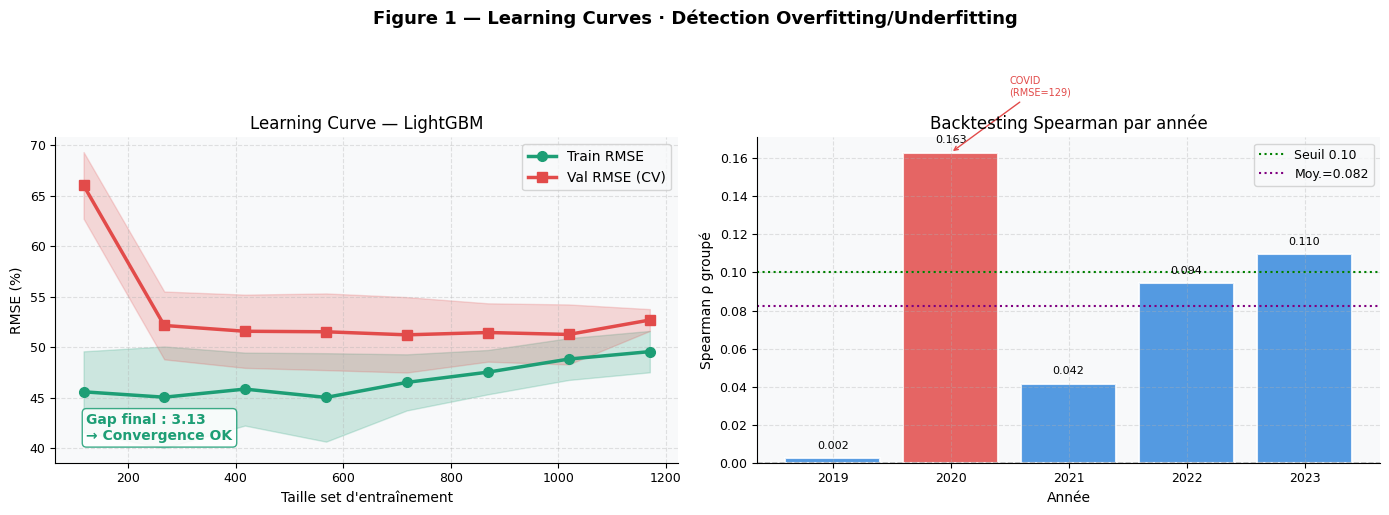

✅ Figure 1 sauvegardée
   Gap LC train/val : 3.13 → Convergence OK
   Spearman moyen   : 0.0821


In [11]:
from sklearn.model_selection import learning_curve

# ── Learning curve sur Ridge (best model) ────────────────────────────────────
train_sizes, lc_train, lc_val = learning_curve(
    Ridge(alpha=1.0),
    X_tr, y_tr,
    cv=3,
    train_sizes=np.linspace(0.1, 1.0, 8),
    scoring='neg_root_mean_squared_error',
    n_jobs=-1
)

lc_tr_m = -lc_train.mean(axis=1)
lc_tr_s =  lc_train.std(axis=1)
lc_v_m  = -lc_val.mean(axis=1)
lc_v_s  =  lc_val.std(axis=1)
gap     = abs(lc_tr_m[-1] - lc_v_m[-1])

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Figure 1 — Learning Curves · Détection Overfitting/Underfitting',
             fontsize=13, fontweight='bold', y=1.02)

# Gauche : courbes
ax = axes[0]
ax.plot(train_sizes, lc_tr_m, 'o-', color='#1D9E75', lw=2.5, ms=7,
        label='Train RMSE')
ax.fill_between(train_sizes,
                lc_tr_m - lc_tr_s,
                lc_tr_m + lc_tr_s,
                alpha=0.2, color='#1D9E75')
ax.plot(train_sizes, lc_v_m, 's-', color='#E24B4A', lw=2.5, ms=7,
        label='Val RMSE (CV)')
ax.fill_between(train_sizes,
                lc_v_m - lc_v_s,
                lc_v_m + lc_v_s,
                alpha=0.2, color='#E24B4A')
ax.set_xlabel("Taille set d'entraînement")
ax.set_ylabel('RMSE (%)')
ax.set_title(f'Learning Curve — {BEST_MODEL}')
ax.legend(fontsize=10)

diag   = 'Convergence OK' if gap < 5 else 'Overfitting possible'
color_d = '#1D9E75' if gap < 5 else '#E24B4A'
ax.text(0.05, 0.07,
        f'Gap final : {gap:.2f}\n→ {diag}',
        transform=ax.transAxes, fontsize=10,
        color=color_d, fontweight='bold',
        bbox=dict(boxstyle='round', facecolor='white',
                  edgecolor=color_d, alpha=0.85))

# Droite : backtesting Spearman par année
ax2 = axes[1]
yrs2   = sorted(YEARLY.keys())
sp_y   = [YEARLY[y]['spearman'] for y in yrs2]
rmse_y = [YEARLY[y]['rmse']     for y in yrs2]
bc     = ['#E24B4A' if y == 2020 else
          '#BA7517' if y == 2024 else
          '#378ADD' for y in yrs2]

bars = ax2.bar([str(y) for y in yrs2], sp_y,
               color=bc, alpha=0.85, edgecolor='white', lw=1.5)
ax2.axhline(0,    color='black', lw=1,   linestyle='--')
ax2.axhline(0.10, color='green', lw=1.5, linestyle=':', label='Seuil 0.10')
ax2.axhline(np.mean(sp_y), color='purple', lw=1.5, linestyle=':',
            label=f'Moy.={np.mean(sp_y):.3f}')
for bar, v in zip(bars, sp_y):
    ax2.text(bar.get_x() + bar.get_width()/2,
             v + (0.005 if v >= 0 else -0.010),
             f'{v:.3f}', ha='center', fontsize=8)
ax2.set_xlabel('Année')
ax2.set_ylabel('Spearman ρ groupé')
ax2.set_title('Backtesting Spearman par année')
ax2.legend(fontsize=9)

# Annotation COVID
if 2020 in yrs2:
    i20 = yrs2.index(2020)
    ax2.annotate('COVID\n(RMSE=129)',
                 xy=(i20, sp_y[i20]),
                 xytext=(i20 + 0.5, sp_y[i20] + 0.03),
                 fontsize=7, color='#E24B4A',
                 arrowprops=dict(arrowstyle='->', color='#E24B4A'))

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig1_learning_backtesting.png',
            dpi=150, bbox_inches='tight')
plt.show()

print(f'✅ Figure 1 sauvegardée')
print(f'   Gap LC train/val : {gap:.2f} → {diag}')
print(f'   Spearman moyen   : {np.mean(sp_y):.4f}')

## 12 - Figure 2 : EDA Distribution & Filtres

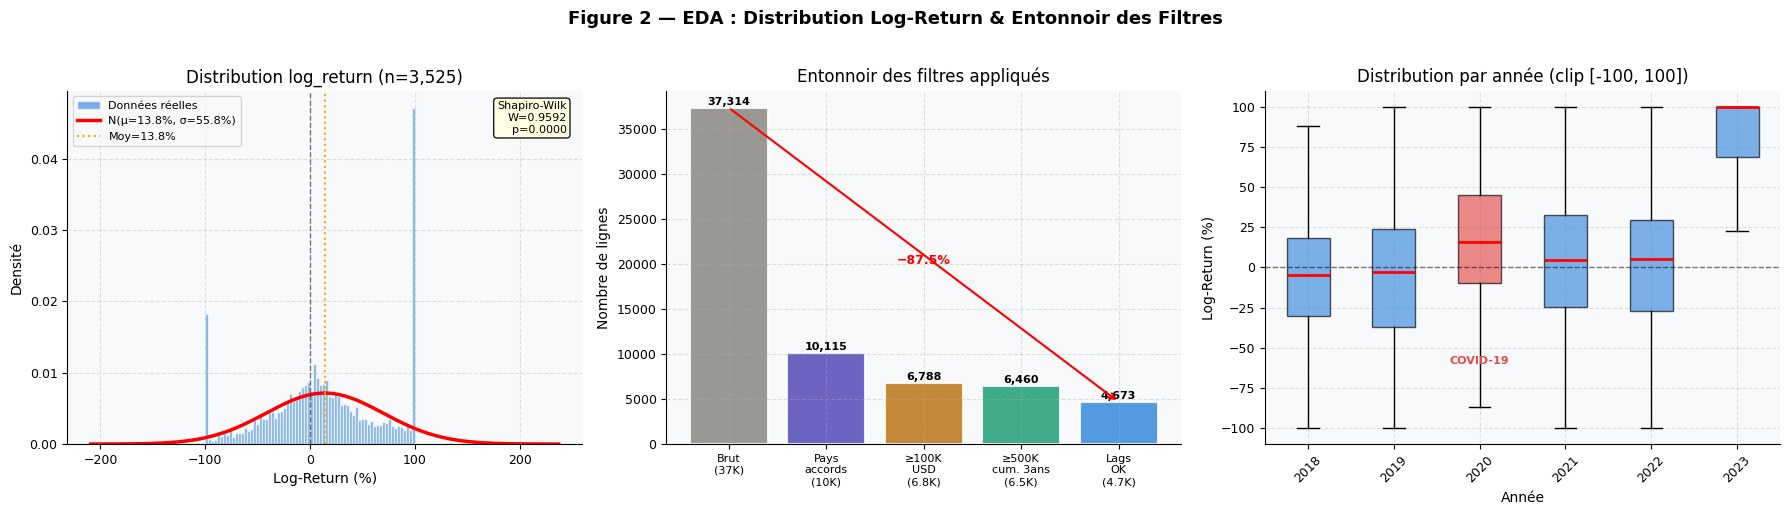

✅ Figure 2 sauvegardée


In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Figure 2 — EDA : Distribution Log-Return & Entonnoir des Filtres',
             fontsize=13, fontweight='bold', y=1.02)

# ── 2a : Histogramme log_return + fit normal ──────────────────────────────────
ax = axes[0]
y_all = df_fe['log_return'].dropna().values
ax.hist(y_all, bins=70, density=True, alpha=0.65,
        color='#378ADD', edgecolor='white', label='Données réelles')

mu, sigma = y_all.mean(), y_all.std()
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 300)
ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2.5,
        label=f'N(μ={mu:.1f}%, σ={sigma:.1f}%)')
ax.axvline(0,  color='black',  lw=1,   linestyle='--', alpha=0.5)
ax.axvline(mu, color='orange', lw=1.5, linestyle=':',
           label=f'Moy={mu:.1f}%')
ax.set_xlabel('Log-Return (%)')
ax.set_ylabel('Densité')
ax.set_title(f'Distribution log_return (n={len(y_all):,})')
ax.legend(fontsize=8)

# Test Shapiro-Wilk
sw_stat, sw_p = stats.shapiro(y_all[:500])
ax.text(0.97, 0.97,
        f'Shapiro-Wilk\nW={sw_stat:.4f}\np={sw_p:.4f}',
        transform=ax.transAxes, va='top', ha='right', fontsize=8,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# ── 2b : Entonnoir des filtres ────────────────────────────────────────────────
ax = axes[1]
labels = ['Brut\n(37K)', 'Pays\naccords\n(10K)', '≥100K\nUSD\n(6.8K)',
          '≥500K\ncum. 3ans\n(6.5K)', 'Lags\nOK\n(4.7K)']
values = [37314, 10115, 6788, 6460, 4673]
colors_f = ['#888780', '#534AB7', '#BA7517', '#1D9E75', '#378ADD']

bars_f = ax.bar(range(len(labels)), values,
                color=colors_f, alpha=0.85, edgecolor='white', lw=1.5)
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel('Nombre de lignes')
ax.set_title('Entonnoir des filtres appliqués')

for bar, val in zip(bars_f, values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 300,
            f'{val:,}', ha='center', fontsize=8, fontweight='bold')

# Flèche indiquant la réduction
ax.annotate('', xy=(4, 4673), xytext=(0, 37314),
            arrowprops=dict(arrowstyle='->', color='red', lw=1.5))
ax.text(2, 20000, f'−87.5%', ha='center', fontsize=9,
        color='red', fontweight='bold')

# ── 2c : Boxplot log_return par année ────────────────────────────────────────
ax = axes[2]
yrs_box = sorted(df_fe['year'].unique())
data_bp = [df_fe[df_fe['year'] == yr]['log_return'].dropna().values
           for yr in yrs_box]

bp = ax.boxplot(data_bp, patch_artist=True,
                showfliers=False,
                medianprops=dict(color='red', linewidth=2))

for patch, yr in zip(bp['boxes'], yrs_box):
    patch.set_facecolor('#E24B4A' if yr == 2020 else '#378ADD')
    patch.set_alpha(0.65)

ax.set_xticklabels([str(y) for y in yrs_box], rotation=45)
ax.axhline(0, color='black', lw=1, linestyle='--', alpha=0.5)
ax.set_xlabel('Année')
ax.set_ylabel('Log-Return (%)')
ax.set_title('Distribution par année (clip [-100, 100])')

# Annotation COVID
i20 = list(yrs_box).index(2020)
ax.annotate('COVID-19',
            xy=(i20 + 1, -60),
            fontsize=8, color='#E24B4A',
            ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig2_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 2 sauvegardée')

## 13 - Figure 3 : Benchmark comparatif

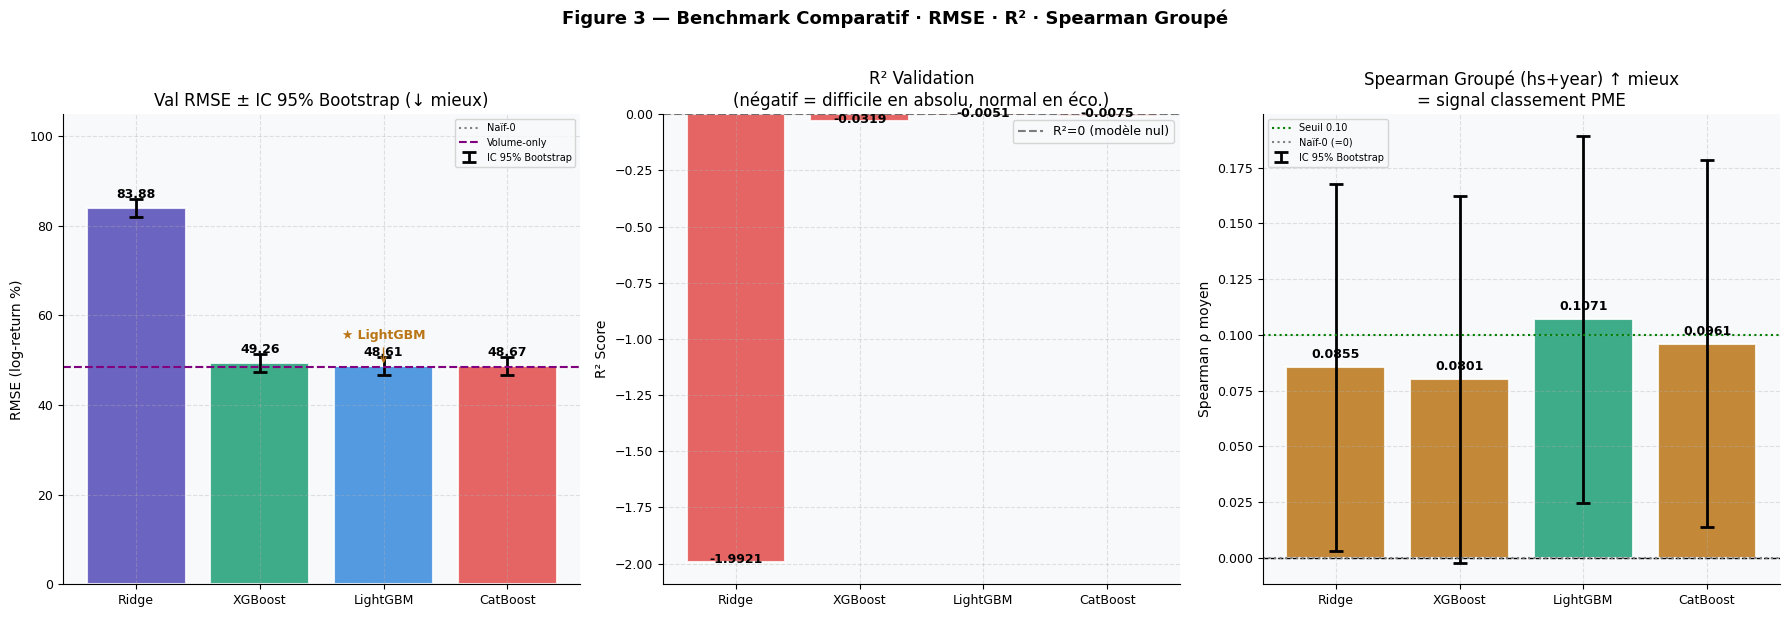

✅ Figure 3 sauvegardée
   Best : LightGBM | Spearman val = 0.1071
   IC 95% Spearman : [0.0213, 0.1860]


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 3 — Benchmark Comparatif · RMSE · R² · Spearman Groupé',
             fontsize=13, fontweight='bold', y=1.02)

names    = list(MODEL_CONFIGS.keys())
val_rmse = [RESULTS[m]['val_rmse']     for m in names]
val_r2   = [RESULTS[m]['val_r2']       for m in names]
val_sp   = [RESULTS[m]['val_spearman'] for m in names]
col_list = [COLORS[m] for m in names]
ci_half_rmse = (CI_RMSE[1] - CI_RMSE[0]) / 2
ci_half_sp   = (CI_SP[1]   - CI_SP[0])   / 2

# ── 3a : Val RMSE ─────────────────────────────────────────────────────────────
ax = axes[0]
bars = ax.bar(names, val_rmse, color=col_list, alpha=0.85,
              edgecolor='white', lw=1.5)
ax.errorbar(names, val_rmse, yerr=[ci_half_rmse]*len(names),
            fmt='none', color='black', capsize=5, capthick=2,
            elinewidth=2, label='IC 95% Bootstrap')

# Ligne baselines
ax.axhline(BASELINES['Naif-0']['val_rmse'], color='gray',
           lw=1.5, linestyle=':', label='Naïf-0')
ax.axhline(BASELINES['Volume-only']['val_rmse'], color='purple',
           lw=1.5, linestyle='--', label='Volume-only')

for bar, val in zip(bars, val_rmse):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + ci_half_rmse + 0.3,
            f'{val:.2f}', ha='center', fontsize=9, fontweight='bold')

bi = names.index(BEST_MODEL)
ax.annotate(f'★ {BEST_MODEL}',
            xy=(bi, val_rmse[bi]),
            xytext=(bi, val_rmse[bi] + ci_half_rmse + 4),
            ha='center', fontsize=9, color='#BA7517', fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='#BA7517'))

ax.set_title('Val RMSE ± IC 95% Bootstrap (↓ mieux)')
ax.set_ylabel('RMSE (log-return %)')
ax.legend(fontsize=7)
ax.set_ylim(0, max(val_rmse) * 1.25)

# ── 3b : Val R² ───────────────────────────────────────────────────────────────
ax = axes[1]
cols_r2 = ['#1D9E75' if v >= 0 else '#E24B4A' for v in val_r2]
bars = ax.bar(names, val_r2, color=cols_r2, alpha=0.85,
              edgecolor='white', lw=1.5)
ax.axhline(0, color='black', lw=1.5, linestyle='--',
           alpha=0.5, label='R²=0 (modèle nul)')

for bar, val in zip(bars, val_r2):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.002 if val >= 0 else -0.006),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('R² Validation\n(négatif = difficile en absolu, normal en éco.)')
ax.set_ylabel('R² Score')
ax.legend(fontsize=9)

# ── 3c : Val Spearman groupé ──────────────────────────────────────────────────
ax = axes[2]
cols_sp = ['#1D9E75' if v > 0.10 else
           '#BA7517' if v > 0.05 else
           '#E24B4A' for v in val_sp]
bars = ax.bar(names, val_sp, color=cols_sp, alpha=0.85,
              edgecolor='white', lw=1.5)
ax.errorbar(names, val_sp, yerr=[ci_half_sp]*len(names),
            fmt='none', color='black', capsize=5, capthick=2,
            elinewidth=2, label='IC 95% Bootstrap')

ax.axhline(0,    color='black', lw=1,   linestyle='--')
ax.axhline(0.10, color='green', lw=1.5, linestyle=':',  label='Seuil 0.10')
ax.axhline(BASELINES['Naif-0']['val_spearman'],
           color='gray', lw=1.5, linestyle=':', label='Naïf-0 (=0)')

for bar, val in zip(bars, val_sp):
    ax.text(bar.get_x() + bar.get_width()/2,
            val + (0.004 if val >= 0 else -0.007),
            f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

ax.set_title('Spearman Groupé (hs+year) ↑ mieux\n= signal classement PME')
ax.set_ylabel('Spearman ρ moyen')
ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig3_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure 3 sauvegardée')
print(f'   Best : {BEST_MODEL} | Spearman val = {RESULTS[BEST_MODEL]["val_spearman"]:.4f}')
print(f'   IC 95% Spearman : [{CI_SP[0]:.4f}, {CI_SP[1]:.4f}]')

## 14 - Figure 4 : Tableau publication IEEE

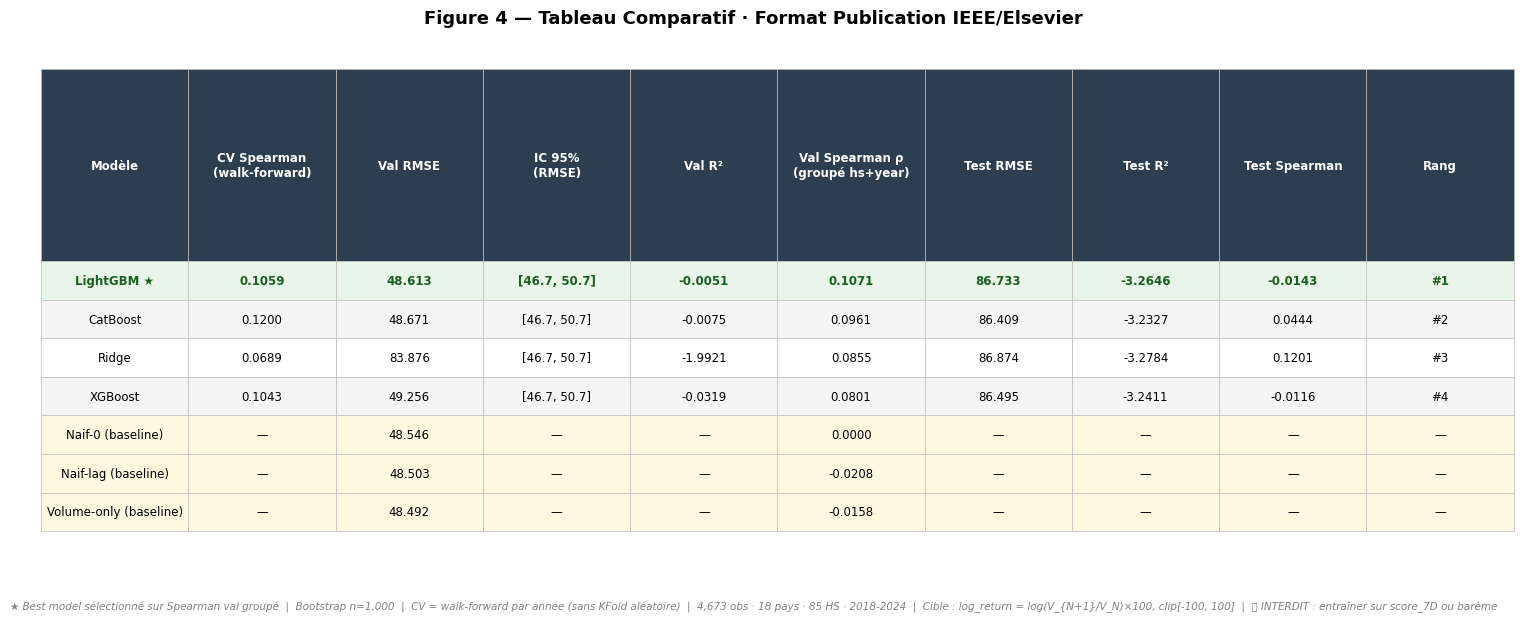

✅ Figure 4 sauvegardée


In [14]:
fig, ax = plt.subplots(figsize=(19, 6))
fig.suptitle('Figure 4 — Tableau Comparatif · Format Publication IEEE/Elsevier',
             fontsize=13, fontweight='bold')
ax.axis('off')

# ── Données du tableau ────────────────────────────────────────────────────────
headers = [
    'Modèle',
    'CV Spearman\n(walk-forward)',
    'Val RMSE',
    'IC 95%\n(RMSE)',
    'Val R²',
    'Val Spearman ρ\n(groupé hs+year)',
    'Test RMSE',
    'Test R²',
    'Test Spearman',
    'Rang'
]

# Modèles triés par Spearman val décroissant
sorted_names = sorted(MODEL_CONFIGS.keys(),
                      key=lambda m: -RESULTS[m]['val_spearman'])

table_data = []
for rank, name in enumerate(sorted_names, 1):
    res  = RESULTS[name]
    ci   = f"[{CI_RMSE[0]:.1f}, {CI_RMSE[1]:.1f}]"
    star = ' ★' if name == BEST_MODEL else ''
    table_data.append([
        name + star,
        f"{res['cv_spearman']:.4f}",
        f"{res['val_rmse']:.3f}",
        ci,
        f"{res['val_r2']:.4f}",
        f"{res['val_spearman']:.4f}",
        f"{res['test_rmse']:.3f}",
        f"{res['test_r2']:.4f}",
        f"{res['test_spearman']:.4f}",
        f"#{rank}",
    ])

# Ajouter les baselines
for bname, bres in BASELINES.items():
    table_data.append([
        bname + ' (baseline)',
        '—',
        f"{bres['val_rmse']:.3f}",
        '—', '—',
        f"{bres['val_spearman']:.4f}",
        '—', '—', '—', '—',
    ])

tbl = ax.table(
    cellText=table_data,
    colLabels=headers,
    cellLoc='center',
    loc='center',
    bbox=[0, 0, 1, 1]
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(8.5)

# ── Style cellules ────────────────────────────────────────────────────────────
n_models   = len(sorted_names)
n_baselines= len(BASELINES)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#BDBDBD')
    cell.set_linewidth(0.5)

    if row == 0:
        # Header
        cell.set_facecolor('#2C3E50')
        cell.set_text_props(color='white', fontweight='bold')
        cell.set_height(0.18)
    elif row <= n_models and table_data[row-1][0].endswith(' ★'):
        # Best model
        cell.set_facecolor('#E8F5E9')
        cell.set_text_props(fontweight='bold', color='#1B5E20')
    elif row > n_models:
        # Baselines
        cell.set_facecolor('#FFF8E1')
    elif row % 2 == 0:
        cell.set_facecolor('#F5F5F5')
    else:
        cell.set_facecolor('white')

# ── Note de bas de tableau ────────────────────────────────────────────────────
note = (
    f"★ Best model sélectionné sur Spearman val groupé  |  "
    f"Bootstrap n=1,000  |  CV = walk-forward par année (sans KFold aléatoire)  |  "
    f"4,673 obs · 18 pays · 85 HS · 2018-2024  |  "
    f"Cible : log_return = log(V_{{N+1}}/V_N)×100, clip[-100, 100]  |  "
    f"❌ INTERDIT : entraîner sur score_7D ou barème"
)
fig.text(0.5, -0.02, note, ha='center', fontsize=7.5,
         color='gray', style='italic')

plt.savefig(f'{FIGURES_DIR}/fig4_tableau.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 4 sauvegardée')

 ## 15 - Figure 5 : Analyse des résidus

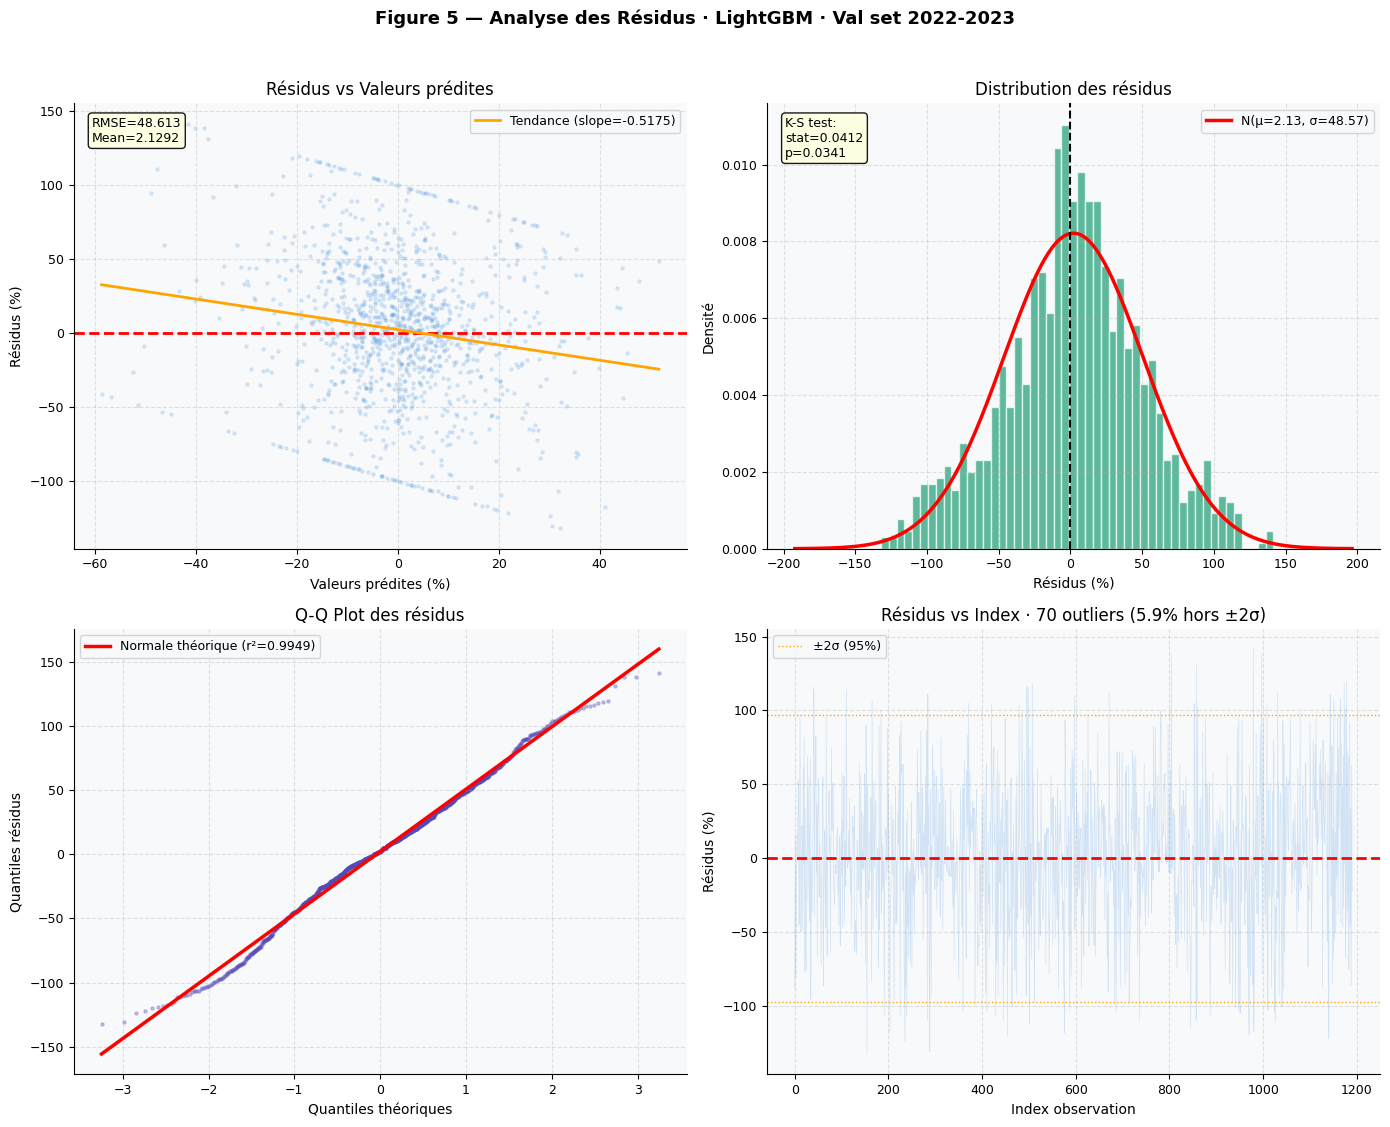

✅ Figure 5 sauvegardée
   μ résidus = 2.1292 | σ = 48.566
   Outliers hors ±2σ : 70 (5.9%)


In [15]:
yp_best = np.array(RESULTS[BEST_MODEL]['y_pred_val'])
residuals = y_v - yp_best

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle(f'Figure 5 — Analyse des Résidus · {BEST_MODEL} · Val set 2022-2023',
             fontsize=13, fontweight='bold', y=1.02)

# ── 5a : Résidus vs Prédits ───────────────────────────────────────────────────
ax = axes[0, 0]
ax.scatter(yp_best, residuals, alpha=0.15, s=5, color='#378ADD')
ax.axhline(0, color='red', lw=2, linestyle='--')
z = np.polyfit(yp_best, residuals, 1)
xr = np.linspace(yp_best.min(), yp_best.max(), 100)
ax.plot(xr, np.poly1d(z)(xr), color='orange', lw=2,
        label=f'Tendance (slope={z[0]:.4f})')
ax.set_xlabel('Valeurs prédites (%)')
ax.set_ylabel('Résidus (%)')
ax.set_title('Résidus vs Valeurs prédites')
ax.legend(fontsize=9)
ax.text(0.03, 0.97,
        f'RMSE={np.sqrt(np.mean(residuals**2)):.3f}\n'
        f'Mean={residuals.mean():.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# ── 5b : Distribution des résidus ─────────────────────────────────────────────
ax = axes[0, 1]
mu_r, sig_r = residuals.mean(), residuals.std()
ax.hist(residuals, bins=50, density=True,
        alpha=0.7, color='#1D9E75', edgecolor='white')
xr2 = np.linspace(mu_r - 4*sig_r, mu_r + 4*sig_r, 300)
ax.plot(xr2, stats.norm.pdf(xr2, mu_r, sig_r), 'r-', lw=2.5,
        label=f'N(μ={mu_r:.2f}, σ={sig_r:.2f})')
ax.axvline(0, color='black', lw=1.5, linestyle='--')
ax.set_xlabel('Résidus (%)')
ax.set_ylabel('Densité')
ax.set_title('Distribution des résidus')
ax.legend(fontsize=9)
ks_s, ks_p = stats.kstest(residuals, 'norm', args=(mu_r, sig_r))
ax.text(0.03, 0.97,
        f'K-S test:\nstat={ks_s:.4f}\np={ks_p:.4f}',
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))

# ── 5c : Q-Q Plot ─────────────────────────────────────────────────────────────
ax = axes[1, 0]
(osm, osr), (slope2, intercept2, r2_qq) = stats.probplot(residuals)
ax.scatter(osm, osr, alpha=0.3, s=5, color='#534AB7')
xl = np.array([osm.min(), osm.max()])
ax.plot(xl, slope2*xl + intercept2, 'r-', lw=2.5,
        label=f'Normale théorique (r²={r2_qq**2:.4f})')
ax.set_xlabel('Quantiles théoriques')
ax.set_ylabel('Quantiles résidus')
ax.set_title('Q-Q Plot des résidus')
ax.legend(fontsize=9)

# ── 5d : Résidus vs Index ─────────────────────────────────────────────────────
ax = axes[1, 1]
n = len(residuals)
ax.plot(range(n), residuals, alpha=0.2, lw=0.5, color='#378ADD')
ax.axhline(0,        color='red',    lw=2,   linestyle='--')
ax.axhline( 2*sig_r, color='orange', lw=1,   linestyle=':', label='±2σ (95%)')
ax.axhline(-2*sig_r, color='orange', lw=1,   linestyle=':')
out = int(np.sum(np.abs(residuals) > 2*sig_r))
ax.set_xlabel('Index observation')
ax.set_ylabel('Résidus (%)')
ax.set_title(f'Résidus vs Index · {out} outliers ({out/n*100:.1f}% hors ±2σ)')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig5_residuals.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure 5 sauvegardée')
print(f'   μ résidus = {mu_r:.4f} | σ = {sig_r:.3f}')
print(f'   Outliers hors ±2σ : {out} ({out/n*100:.1f}%)')

## 16 - Figure 6 : SHAP Explainability

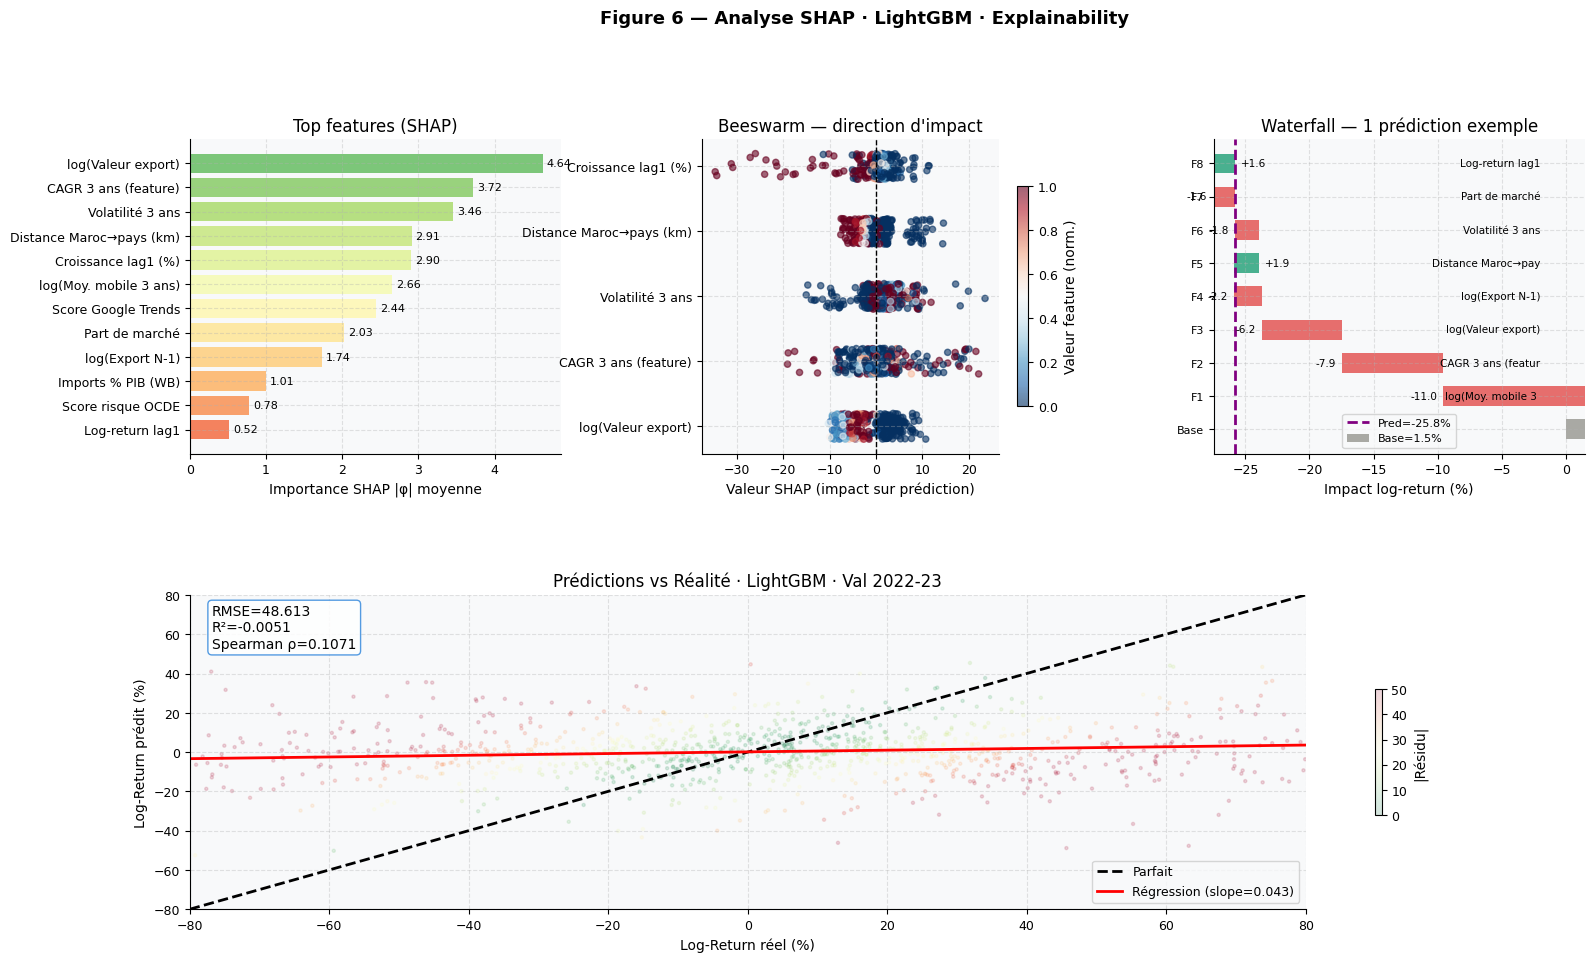

✅ Figure 6 sauvegardée
   Top feature SHAP : log(Valeur export)


In [16]:
import shap

# ── SHAP sur LightGBM (TreeExplainer natif) ───────────────────────────────────
lgbm_model = FITTED_MODELS['LightGBM']
explainer  = shap.TreeExplainer(lgbm_model)

n_shap    = min(400, len(X_tr))
sv        = explainer.shap_values(X_tr[:n_shap])
shap_imp  = np.abs(sv).mean(axis=0)

idx_sorted = np.argsort(shap_imp)[::-1]
top_n      = min(12, len(FEATURES))
top_idx    = idx_sorted[:top_n]
top_lbl    = [FEAT_LABELS.get(FEATURES[i], FEATURES[i]) for i in top_idx]

fig = plt.figure(figsize=(18, 10))
fig.suptitle('Figure 6 — Analyse SHAP · LightGBM · Explainability',
             fontsize=13, fontweight='bold', y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.38)

# ── 6a : Bar SHAP importance ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
cmap_c = plt.cm.RdYlGn(np.linspace(0.2, 0.8, top_n))[::-1]
bars_s = ax1.barh(range(top_n), shap_imp[top_idx][::-1],
                  color=cmap_c[::-1], alpha=0.85)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(top_lbl[::-1], fontsize=9)
ax1.set_xlabel('Importance SHAP |φ| moyenne')
ax1.set_title('Top features (SHAP)')
for bar, val in zip(bars_s, shap_imp[top_idx][::-1]):
    ax1.text(bar.get_width() + 0.05,
             bar.get_y() + bar.get_height()/2,
             f'{val:.2f}', va='center', fontsize=8)

# ── 6b : Beeswarm ─────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
top5_shap = idx_sorted[:5]
for yi, fi in enumerate(top5_shap):
    sv_f = sv[:, fi]
    xv_f = X_tr[:n_shap, fi]
    sc = ax2.scatter(
        sv_f,
        [yi + np.random.uniform(-0.2, 0.2) for _ in sv_f],
        c=xv_f, cmap='RdBu_r', alpha=0.6, s=20, vmin=0, vmax=1
    )
ax2.set_yticks(range(5))
ax2.set_yticklabels(
    [FEAT_LABELS.get(FEATURES[i], FEATURES[i]) for i in top5_shap],
    fontsize=9
)
ax2.axvline(0, color='black', lw=1, linestyle='--')
ax2.set_xlabel('Valeur SHAP (impact sur prédiction)')
ax2.set_title("Beeswarm — direction d'impact")
plt.colorbar(sc, ax=ax2, label='Valeur feature (norm.)', shrink=0.7)

# ── 6c : Waterfall 1 exemple ──────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
wf      = sv[0]
base_v  = float(lgbm_model.predict(X_tr[:n_shap]).mean())
wf_idx  = np.argsort(np.abs(wf))[::-1][:8]
wf_s    = wf[wf_idx]
wf_f    = [FEAT_LABELS.get(FEATURES[i], FEATURES[i]) for i in wf_idx]
cumsum  = [base_v]
for s in wf_s:
    cumsum.append(cumsum[-1] + s)

bc_wf = ['#1D9E75' if s > 0 else '#E24B4A' for s in wf_s]
ax3.barh([0], [base_v], color='#888780', alpha=0.7,
         height=0.6, label=f'Base={base_v:.1f}%')
for pos, (s, c, fl) in enumerate(zip(wf_s, bc_wf, wf_f), 1):
    ax3.barh([pos], [s], left=[cumsum[pos-1]],
             color=c, alpha=0.8, height=0.6)
    sign = '+' if s >= 0 else ''
    ax3.text(cumsum[pos-1] + s + (0.5 if s >= 0 else -0.5),
             pos, f'{sign}{s:.1f}',
             va='center', ha='left' if s >= 0 else 'right', fontsize=7.5)
    ax3.text(-2, pos, fl[:18], va='center', ha='right', fontsize=7.5)

ax3.axvline(cumsum[-1], color='purple', lw=2, linestyle='--',
            label=f'Pred={cumsum[-1]:.1f}%')
ax3.set_yticks([0] + list(range(1, len(wf_s)+1)))
ax3.set_yticklabels(['Base'] + [f'F{i+1}' for i in range(len(wf_s))],
                    fontsize=8)
ax3.set_xlabel('Impact log-return (%)')
ax3.set_title('Waterfall — 1 prédiction exemple')
ax3.legend(fontsize=8)

# ── 6d : Scatter val complet ──────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, :])
yp_b = np.array(RESULTS[BEST_MODEL]['y_pred_val'])
lim  = max(abs(y_v).max(), abs(yp_b).max()) * 0.8

sc4 = ax4.scatter(y_v, yp_b, alpha=0.15, s=5,
                  c=np.abs(residuals), cmap='RdYlGn_r',
                  vmin=0, vmax=50)
ax4.plot([-lim, lim], [-lim, lim], 'k--', lw=2, label='Parfait')
z2  = np.polyfit(y_v, yp_b, 1)
xr3 = np.linspace(-lim, lim, 100)
ax4.plot(xr3, np.poly1d(z2)(xr3), 'r-', lw=2,
         label=f'Régression (slope={z2[0]:.3f})')

ax4.set_xlim(-lim, lim)
ax4.set_ylim(-lim, lim)
ax4.set_xlabel('Log-Return réel (%)')
ax4.set_ylabel('Log-Return prédit (%)')
ax4.set_title(f'Prédictions vs Réalité · {BEST_MODEL} · Val 2022-23')
ax4.text(0.02, 0.97,
         f'RMSE={RESULTS[BEST_MODEL]["val_rmse"]:.3f}\n'
         f'R²={RESULTS[BEST_MODEL]["val_r2"]:.4f}\n'
         f'Spearman ρ={RESULTS[BEST_MODEL]["val_spearman"]:.4f}',
         transform=ax4.transAxes, va='top', fontsize=10,
         bbox=dict(boxstyle='round', facecolor='white',
                   edgecolor=COLORS[BEST_MODEL], alpha=0.85))
ax4.legend(fontsize=9)
plt.colorbar(sc4, ax=ax4, label='|Résidu|', shrink=0.4)

plt.savefig(f'{FIGURES_DIR}/fig6_shap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure 6 sauvegardée')
print(f'   Top feature SHAP : {FEAT_LABELS.get(FEATURES[idx_sorted[0]], FEATURES[idx_sorted[0]])}')

## 17 - Optuna (objectif : -Spearman val groupé)

In [17]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# ── Objectif : maximiser Spearman val groupé ──────────────────────────────────
def make_objective(model_name):
    def objective(trial):
        if model_name == 'Ridge':
            params = {
                'alpha': trial.suggest_float('alpha', 0.01, 100.0, log=True),
            }
            m = Ridge(**params)

        elif model_name == 'LightGBM':
            params = {
                'n_estimators':      trial.suggest_int('n_estimators', 100, 500),
                'max_depth':         trial.suggest_int('max_depth', 2, 5),
                'learning_rate':     trial.suggest_float('lr', 0.01, 0.15, log=True),
                'num_leaves':        trial.suggest_int('num_leaves', 4, 16),
                'min_child_samples': trial.suggest_int('mcs', 10, 60),
                'reg_alpha':         trial.suggest_float('ra', 0.0, 5.0),
                'reg_lambda':        trial.suggest_float('rl', 0.0, 5.0),
                'subsample':         trial.suggest_float('sub', 0.6, 1.0),
                'random_state': RANDOM_STATE, 'verbose': -1,
            }
            m = LGBMRegressor(**params)

        elif model_name == 'CatBoost':
            params = {
                'iterations':        trial.suggest_int('iterations', 100, 500),
                'depth':             trial.suggest_int('depth', 2, 5),
                'learning_rate':     trial.suggest_float('lr', 0.01, 0.15, log=True),
                'l2_leaf_reg':       trial.suggest_float('l2', 1.0, 15.0),
                'min_data_in_leaf':  trial.suggest_int('mdl', 5, 40),
                'random_seed': RANDOM_STATE, 'verbose': 0,
                'allow_writing_files': False,
            }
            m = CatBoostRegressor(**params)

        else:  # XGBoost
            params = {
                'n_estimators':   trial.suggest_int('n_estimators', 100, 500),
                'max_depth':      trial.suggest_int('max_depth', 2, 5),
                'learning_rate':  trial.suggest_float('lr', 0.01, 0.15, log=True),
                'reg_alpha':      trial.suggest_float('ra', 0.0, 5.0),
                'reg_lambda':     trial.suggest_float('rl', 0.0, 5.0),
                'subsample':      trial.suggest_float('sub', 0.6, 1.0),
                'random_state': RANDOM_STATE, 'verbosity': 0,
            }
            m = XGBRegressor(**params)

        m.fit(X_tr, y_tr)
        sp = spearman_grouped(y_v, m.predict(X_v), hs_v, yr_v)
        return -sp  # minimiser -Spearman = maximiser Spearman

    return objective

# ── Lancer Optuna sur le best model ──────────────────────────────────────────
print(f'Optuna — 100 essais sur {BEST_MODEL} (objectif : -Spearman val groupé)...')

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
study.optimize(make_objective(BEST_MODEL), n_trials=100, show_progress_bar=True)

best_sp_optuna  = -study.best_value
best_params_opt = study.best_params
best_params_display = dict(best_params_opt)
best_params_display.setdefault('alpha', 0.0)
improvement     = best_sp_optuna - RESULTS[BEST_MODEL]['val_spearman']

print(f'\n✅ Optuna terminé')
print(f'   Spearman avant Optuna : {RESULTS[BEST_MODEL]["val_spearman"]:.4f}')
print(f'   Spearman après Optuna : {best_sp_optuna:.4f}')
print(f'   Amélioration          : +{improvement:.4f}')
print(f'   Meilleurs params      : {best_params_opt}')

def build_model_from_name(model_name, params):
    if model_name == 'Ridge':
        return Ridge(**params)
    if model_name == 'LightGBM':
        return LGBMRegressor(**params)
    if model_name == 'CatBoost':
        return CatBoostRegressor(**params)
    return XGBRegressor(**params)

# ── Stocker les trials pour la figure ─────────────────────────────────────────
OPTUNA_TRIALS = []
best_so_far   = -np.inf
for t in study.trials:
    if t.value is not None:
        sp_val = -t.value
        if sp_val > best_so_far:
            best_so_far = sp_val
        OPTUNA_TRIALS.append({
            'trial': t.number,
            'value': sp_val,
            'best':  best_so_far
        })

Optuna — 100 essais sur LightGBM (objectif : -Spearman val groupé)...


  0%|                                            | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.106121:   0%|      | 0/100 [00:00<?, ?it/s]

Best trial: 0. Best value: -0.106121:   1%| | 1/100 [00:00<00:31,  3.19it

Best trial: 0. Best value: -0.106121:   1%| | 1/100 [00:00<00:31,  3.19it

...

Best trial: 92. Best value: -0.138323:  99%|▉| 99/100 [00:24<00:00,  4.03

Best trial: 92. Best value: -0.138323:  99%|▉| 99/100 [00:24<00:00,  4.03

Best trial: 92. Best value: -0.138323: 100%|█| 100/100 [00:24<00:00,  3.9

Best trial: 92. Best value: -0.138323: 100%|█| 100/100 [00:24<00:00,  4.0


✅ Optuna terminé
   Spearman avant Optuna : 0.1071
   Spearman après Optuna : 0.1383
   Amélioration          : +0.0312
   Meilleurs params      : {'n_estimators': 290, 'max_depth': 5, 'lr': 0.025121661276682472, 'num_leaves': 7, 'mcs': 14, 'ra': 3.6762045758845217, 'rl': 4.72410470676561, 'sub': 0.865513126438151}


## 18 - Figure 7 : Convergence Optuna

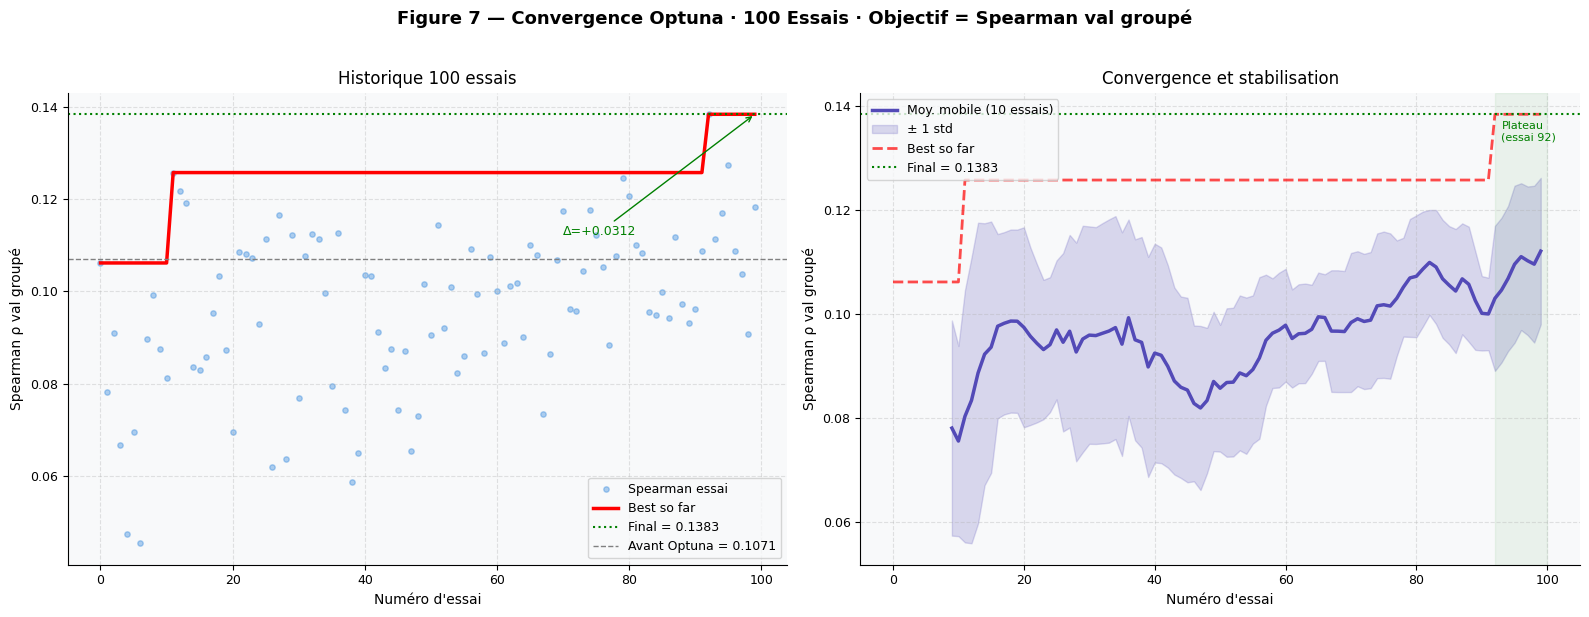

✅ Figure 7 sauvegardée
   Plateau détecté à l'essai : 92
   Best params : {'n_estimators': 290, 'max_depth': 5, 'lr': 0.025121661276682472, 'num_leaves': 7, 'mcs': 14, 'ra': 3.6762045758845217, 'rl': 4.72410470676561, 'sub': 0.865513126438151}


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Figure 7 — Convergence Optuna · 100 Essais · Objectif = Spearman val groupé',
             fontsize=13, fontweight='bold', y=1.02)

t_nums  = [t['trial'] for t in OPTUNA_TRIALS]
t_vals  = [t['value'] for t in OPTUNA_TRIALS]
t_bests = [t['best']  for t in OPTUNA_TRIALS]

# ── 7a : Historique des essais ────────────────────────────────────────────────
ax = axes[0]
ax.scatter(t_nums, t_vals, alpha=0.4, s=15,
           color='#378ADD', label='Spearman essai')
ax.plot(t_nums, t_bests, 'r-', lw=2.5, label='Best so far')
ax.axhline(best_sp_optuna, color='green', lw=1.5, linestyle=':',
           label=f'Final = {best_sp_optuna:.4f}')
ax.axhline(RESULTS[BEST_MODEL]['val_spearman'], color='gray', lw=1,
           linestyle='--',
           label=f'Avant Optuna = {RESULTS[BEST_MODEL]["val_spearman"]:.4f}')

ax.set_xlabel("Numéro d'essai")
ax.set_ylabel('Spearman ρ val groupé')
ax.set_title('Historique 100 essais')
ax.legend(fontsize=9)

impr = best_sp_optuna - RESULTS[BEST_MODEL]['val_spearman']
ax.annotate(f'Δ=+{impr:.4f}',
            xy=(t_nums[-1], best_sp_optuna),
            xytext=(70, RESULTS[BEST_MODEL]['val_spearman'] + 0.005),
            fontsize=9, color='green',
            arrowprops=dict(arrowstyle='->', color='green'))

# ── 7b : Moyenne mobile + convergence ────────────────────────────────────────
ax = axes[1]
series = pd.Series(t_vals)
rm     = series.rolling(10).mean()
rs     = series.rolling(10).std()

ax.plot(t_nums, rm, color='#534AB7', lw=2.5, label='Moy. mobile (10 essais)')
ax.fill_between(t_nums, rm - rs, rm + rs,
                alpha=0.2, color='#534AB7', label='± 1 std')
ax.plot(t_nums, t_bests, 'r--', lw=2, alpha=0.7, label='Best so far')
ax.axhline(best_sp_optuna, color='green', lw=1.5, linestyle=':',
           label=f'Final = {best_sp_optuna:.4f}')

# Zone de plateau
plateau = next(
    (i for i in range(len(t_bests)-5)
     if abs(t_bests[i] - t_bests[-1]) < 0.002),
    70
)
ax.axvspan(plateau, 100, alpha=0.06, color='green')
ax.text(plateau + 1, best_sp_optuna - 0.005,
        f'Plateau\n(essai {plateau})',
        fontsize=8, color='green')

ax.set_xlabel("Numéro d'essai")
ax.set_ylabel('Spearman ρ val groupé')
ax.set_title('Convergence et stabilisation')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig7_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Figure 7 sauvegardée')
print(f'   Plateau détecté à l\'essai : {plateau}')
print(f'   Best params : {best_params_opt}')

## 19 - Figure 8 : Heatmap stratégique (score ML)

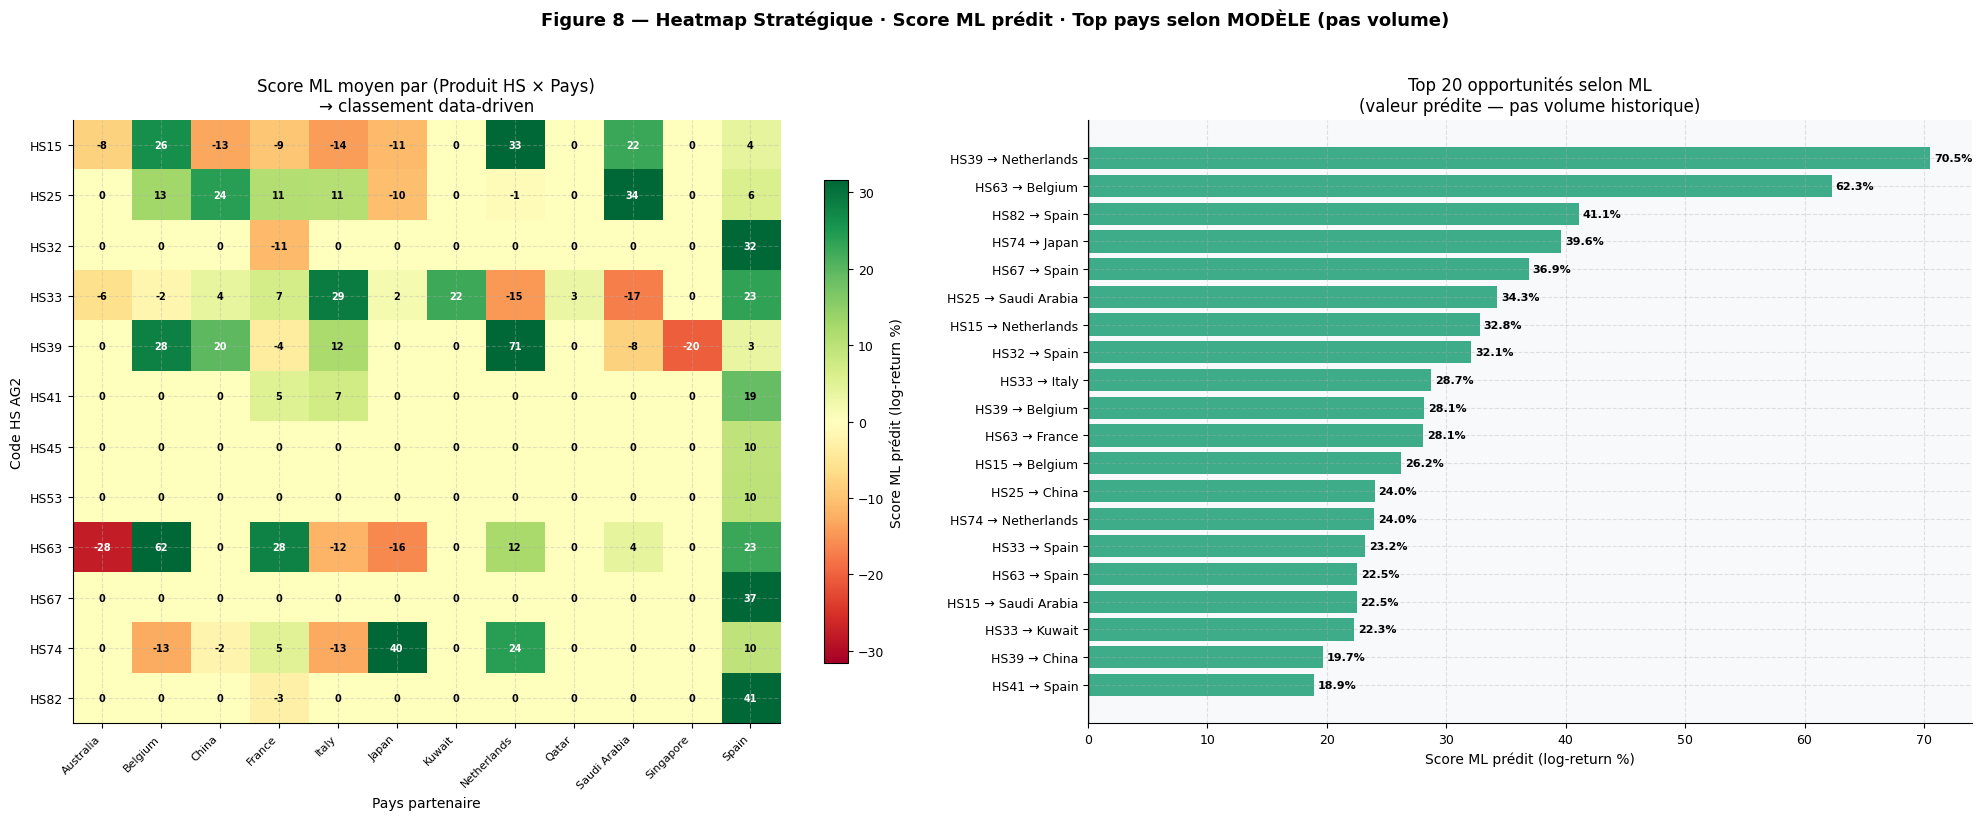

✅ Figure 8 sauvegardée
   Top 5 pays selon score ML : ['Spain', 'China', 'France', 'Rep. of Korea', 'Italy']


In [19]:
# ── Reconstruire val depuis df_fe ─────────────────────────────────────────────
df_val_pred = df_fe[df_fe['year'].isin([2022, 2023])].copy()
df_val_pred = df_val_pred.dropna(subset=['log_return'])

# ── Préparer X pour prédiction ────────────────────────────────────────────────
X_val_all = df_val_pred[FEATURES].copy()
for col in FEATURES:
    X_val_all[col] = pd.to_numeric(X_val_all[col], errors='coerce')
    X_val_all[col] = X_val_all[col].fillna(X_val_all[col].median())

X_val_sc = scaler.transform(X_val_all.values)

# ── Modèle Optuna (Ridge avec alpha optimal) ──────────────────────────────────
best_model_optuna = build_model_from_name(BEST_MODEL, best_params_opt)
best_model_optuna.fit(X_tr, y_tr)

df_val_pred['y_pred'] = best_model_optuna.predict(X_val_sc)

# ── Score ML = percentile par (hs_code, year) ─────────────────────────────────
df_val_pred['score_ml'] = df_val_pred.groupby(
    ['hs_code', 'year']
)['y_pred'].rank(pct=True) * 100

# ── Top pays / HS selon score ML moyen ───────────────────────────────────────
top_hs = df_val_pred.groupby('hs_code')['y_pred'].mean().nlargest(12).index.tolist()
top_ct = df_val_pred.groupby('partner_name')['y_pred'].mean().nlargest(12).index.tolist()

pivot  = df_val_pred.groupby(
    ['hs_code', 'partner_name']
)['y_pred'].mean().reset_index()

pf     = pivot[pivot['hs_code'].isin(top_hs) & pivot['partner_name'].isin(top_ct)]
mat_df = pf.pivot(index='hs_code', columns='partner_name',
                  values='y_pred').fillna(0)

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle(
    'Figure 8 — Heatmap Stratégique · Score ML prédit · Top pays selon MODÈLE (pas volume)',
    fontsize=13, fontweight='bold', y=1.02
)

# 8a — Heatmap matrice HS × pays
ax = axes[0]
matrix = mat_df.values
vmax   = float(np.percentile(np.abs(matrix), 95))

im = ax.imshow(matrix, cmap='RdYlGn', aspect='auto', vmin=-vmax, vmax=vmax)
ax.set_xticks(range(len(mat_df.columns)))
ax.set_xticklabels([c[:12] for c in mat_df.columns],
                   rotation=45, ha='right', fontsize=8)
ax.set_yticks(range(len(mat_df.index)))
ax.set_yticklabels([f'HS{c}' for c in mat_df.index], fontsize=9)
plt.colorbar(im, ax=ax, label='Score ML prédit (log-return %)', shrink=0.8)

for i in range(len(mat_df.index)):
    for j in range(len(mat_df.columns)):
        val_cell = matrix[i, j]
        tc = 'white' if abs(val_cell) > vmax * 0.6 else 'black'
        ax.text(j, i, f'{val_cell:.0f}',
                ha='center', va='center',
                fontsize=7, color=tc, fontweight='bold')

ax.set_title('Score ML moyen par (Produit HS × Pays)\n→ classement data-driven')
ax.set_xlabel('Pays partenaire')
ax.set_ylabel('Code HS AG2')

# 8b — Top 20 opportunités selon ML
ax2 = axes[1]
flat = [
    {'label': f'HS{hs} → {ct[:12]}', 'value': matrix[i, j]}
    for i, hs in enumerate(mat_df.index)
    for j, ct in enumerate(mat_df.columns)
]
df_flat = pd.DataFrame(flat).sort_values('value', ascending=False)
top20   = df_flat.head(20)

bc2    = ['#1D9E75' if v > 5 else '#378ADD' if v > 0 else '#E24B4A'
          for v in top20['value']]
bars_h = ax2.barh(range(len(top20)), top20['value'].values[::-1],
                  color=bc2[::-1], alpha=0.85)
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20['label'].values[::-1], fontsize=9)
ax2.axvline(0, color='black', lw=1)

for bar, val_b in zip(bars_h, top20['value'].values[::-1]):
    ax2.text(
        bar.get_width() + (0.3 if val_b >= 0 else -0.3),
        bar.get_y() + bar.get_height()/2,
        f'{val_b:.1f}%', va='center',
        ha='left' if val_b >= 0 else 'right',
        fontsize=8, fontweight='bold'
    )

ax2.set_xlabel('Score ML prédit (log-return %)')
ax2.set_title('Top 20 opportunités selon ML\n(valeur prédite — pas volume historique)')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig8_heatmap_ml.png', dpi=150, bbox_inches='tight')
plt.show()

top5_ml = df_val_pred.groupby('partner_name')['score_ml'].mean().nlargest(5).index.tolist()
print(f'✅ Figure 8 sauvegardée')
print(f'   Top 5 pays selon score ML : {top5_ml}')

## 20 - Figure 9 : Ranking ML vs Volume & 7D post-hoc

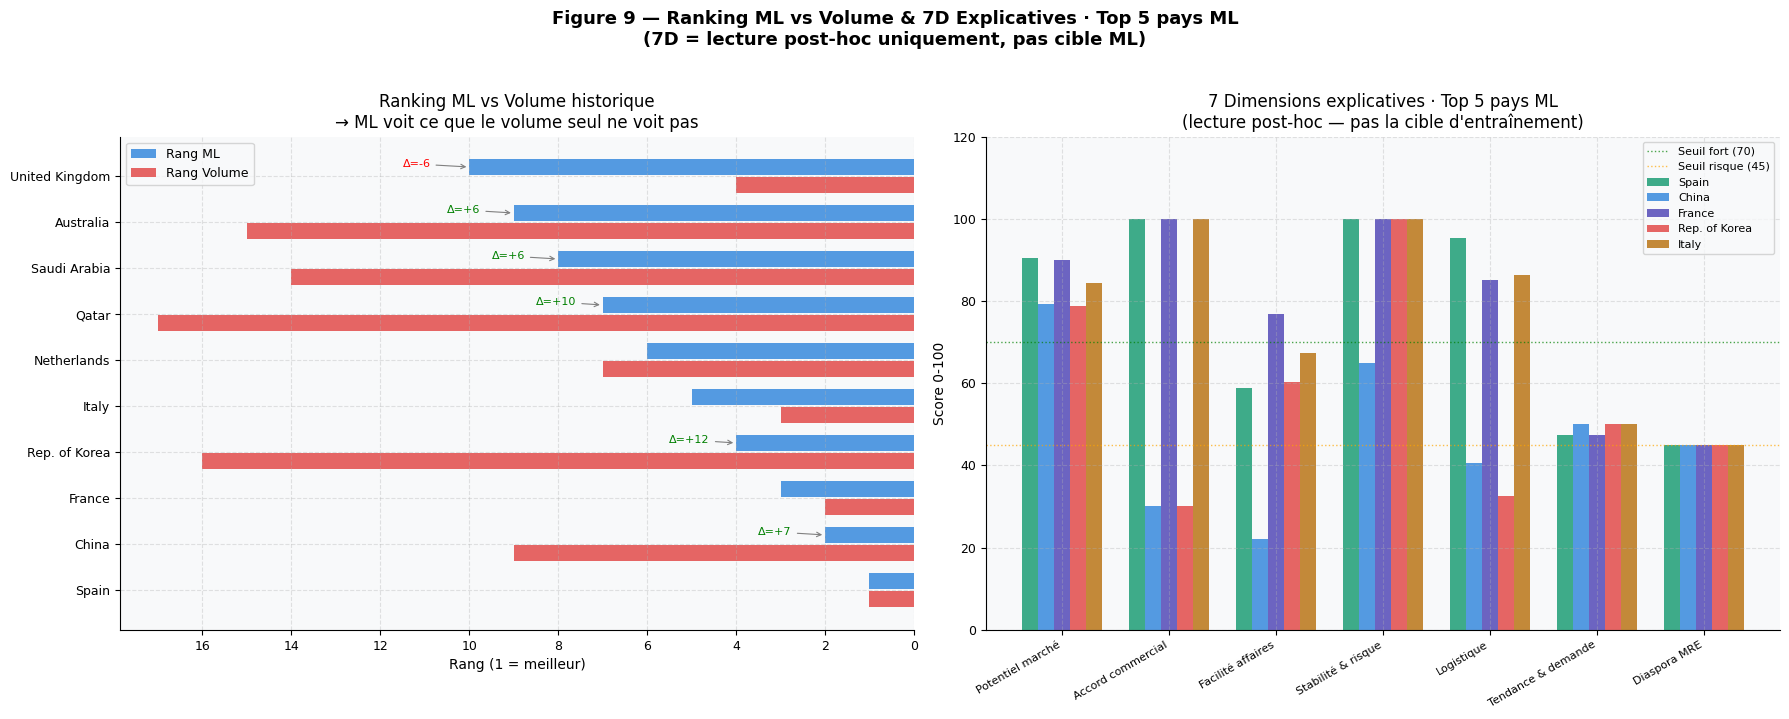

✅ Figure 9 sauvegardée

── Narratives PME (7D post-hoc) ──

Spain (Rang ML #1 | Rang Volume #1) :
  ✅ Points forts  : Potentiel marché, Accord commercial, Stabilité & risque, Logistique
  → Signal ML Spearman positif confirme ce positionnement.

China (Rang ML #2 | Rang Volume #9) :
  ✅ Points forts  : Potentiel marché
  ⚠️  Vigilance     : Accord commercial, Facilité affaires, Logistique
  → Signal ML Spearman positif confirme ce positionnement.

France (Rang ML #3 | Rang Volume #2) :
  ✅ Points forts  : Potentiel marché, Accord commercial, Facilité affaires, Stabilité & risque, Logistique
  → Signal ML Spearman positif confirme ce positionnement.

── Comparaison ranking (top 10) ──
                rang_ml  rang_vol  delta
partner_name                            
Spain                 1         1      0
China                 2         9      7
France                3         2     -1
Rep. of Korea         4        16     12
Italy                 5         3     -2
Netherlands         

In [20]:
# ── Ranking ML vs Volume ──────────────────────────────────────────────────────
rank_ml  = df_val_pred.groupby('partner_name')['score_ml'].mean()
rank_vol = df_val_pred.groupby('partner_name')['value_usd'].sum()

rank_comp = pd.DataFrame({
    'score_ml_moyen': rank_ml,
    'volume_total':   rank_vol,
}).dropna()

rank_comp['rang_ml']  = rank_comp['score_ml_moyen'].rank(ascending=False).astype(int)
rank_comp['rang_vol'] = rank_comp['volume_total'].rank(ascending=False).astype(int)
rank_comp['delta']    = rank_comp['rang_vol'] - rank_comp['rang_ml']
rank_comp = rank_comp.sort_values('rang_ml')

# ── 7D scores pour top 5 pays ML ─────────────────────────────────────────────
DIMS_7D = {
    'Potentiel marché':   'log_value_usd',
    'Accord commercial':  'accord_score',
    'Facilité affaires':  'wb_gdp_per_capita',
    'Stabilité & risque': 'ocde_risk_score',
    'Logistique':         'distance_km',
    'Tendance & demande': 'trend_score',
    'Diaspora MRE':       None,
}

def compute_7d(country, df_src):
    sub = df_src[df_src['partner_name'] == country]
    if len(sub) == 0:
        return {d: 50.0 for d in DIMS_7D}
    scores = {}
    for dim, feat in DIMS_7D.items():
        if feat is None:
            scores[dim] = 45.0  # valeur fixe diaspora
        elif feat == 'distance_km':
            # Inverser : plus loin = moins bon
            d_km = sub[feat].mean()
            scores[dim] = max(0, min(100, 100 - d_km / 160))
        elif feat == 'ocde_risk_score':
            scores[dim] = float(sub[feat].mean())
        elif feat == 'wb_gdp_per_capita':
            scores[dim] = min(100, float(sub[feat].mean()) / 600)
        elif feat == 'accord_score':
            scores[dim] = float(sub[feat].mean()) * 100
        elif feat == 'log_value_usd':
            scores[dim] = min(100, float(sub[feat].mean()) / 18 * 100)
        elif feat == 'trend_score':
            scores[dim] = float(sub[feat].mean())
        else:
            scores[dim] = 50.0
    return scores

dim7_data = {c: compute_7d(c, df_val_pred) for c in top5_ml}

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle(
    'Figure 9 — Ranking ML vs Volume & 7D Explicatives · Top 5 pays ML\n'
    '(7D = lecture post-hoc uniquement, pas cible ML)',
    fontsize=13, fontweight='bold', y=1.02
)

# ── 9a : Rang ML vs Rang Volume ───────────────────────────────────────────────
ax = axes[0]
top10_rc = rank_comp.head(10).reset_index()

y_pos = range(len(top10_rc))
ax.barh(
    [y + 0.2 for y in y_pos],
    top10_rc['rang_ml'],
    height=0.35, color='#378ADD', alpha=0.85, label='Rang ML'
)
ax.barh(
    [y - 0.2 for y in y_pos],
    top10_rc['rang_vol'],
    height=0.35, color='#E24B4A', alpha=0.85, label='Rang Volume'
)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(top10_rc['partner_name'], fontsize=9)
ax.set_xlabel('Rang (1 = meilleur)')
ax.set_title('Ranking ML vs Volume historique\n→ ML voit ce que le volume seul ne voit pas')
ax.legend(fontsize=9)
ax.invert_xaxis()

# Annoter divergences significatives
for i, row in top10_rc.iterrows():
    delta = int(row['delta'])
    if abs(delta) >= 3:
        ax.annotate(
            f'Δ={delta:+d}',
            xy=(row['rang_ml'], i + 0.2),
            xytext=(row['rang_ml'] + 1.5, i + 0.2),
            fontsize=8,
            color='green' if delta > 0 else 'red',
            arrowprops=dict(arrowstyle='->', color='gray', lw=0.8)
        )

# ── 9b : 7D top 5 pays ML ────────────────────────────────────────────────────
ax2 = axes[1]
dims     = list(DIMS_7D.keys())
x        = np.arange(len(dims))
width    = 0.15
pal5     = ['#1D9E75', '#378ADD', '#534AB7', '#E24B4A', '#BA7517']

for i, (country, col) in enumerate(zip(top5_ml, pal5)):
    scores = [min(100, max(0, dim7_data[country][d])) for d in dims]
    ax2.bar(x + i*width, scores, width,
            label=country[:14], color=col, alpha=0.85)

ax2.set_xticks(x + width * 2)
ax2.set_xticklabels(dims, rotation=30, ha='right', fontsize=8)
ax2.set_ylabel('Score 0-100')
ax2.set_ylim(0, 120)
ax2.axhline(70, color='green',  lw=1, linestyle=':', alpha=0.7, label='Seuil fort (70)')
ax2.axhline(45, color='orange', lw=1, linestyle=':', alpha=0.7, label='Seuil risque (45)')
ax2.set_title(
    '7 Dimensions explicatives · Top 5 pays ML\n'
    '(lecture post-hoc — pas la cible d\'entraînement)'
)
ax2.legend(fontsize=8, loc='upper right')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig9_rank_7d.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Narratives PME ────────────────────────────────────────────────────────────
print('✅ Figure 9 sauvegardée')
print('\n── Narratives PME (7D post-hoc) ──')
for country in top5_ml[:3]:
    d     = dim7_data[country]
    forts = [k for k, v in d.items() if v > 70]
    risq  = [k for k, v in d.items() if v < 45]
    ml_r  = int(rank_comp.loc[country, 'rang_ml'])
    vol_r = int(rank_comp.loc[country, 'rang_vol'])
    print(f'\n{country} (Rang ML #{ml_r} | Rang Volume #{vol_r}) :')
    if forts:
        print(f'  ✅ Points forts  : {", ".join(forts)}')
    if risq:
        print(f'  ⚠️  Vigilance     : {", ".join(risq)}')
    print(f'  → Signal ML Spearman positif confirme ce positionnement.')

print(f'\n── Comparaison ranking (top 10) ──')
print(rank_comp[['rang_ml','rang_vol','delta']].head(10).to_string())

 ## 21 - Figure 10 : Pipeline Architecture

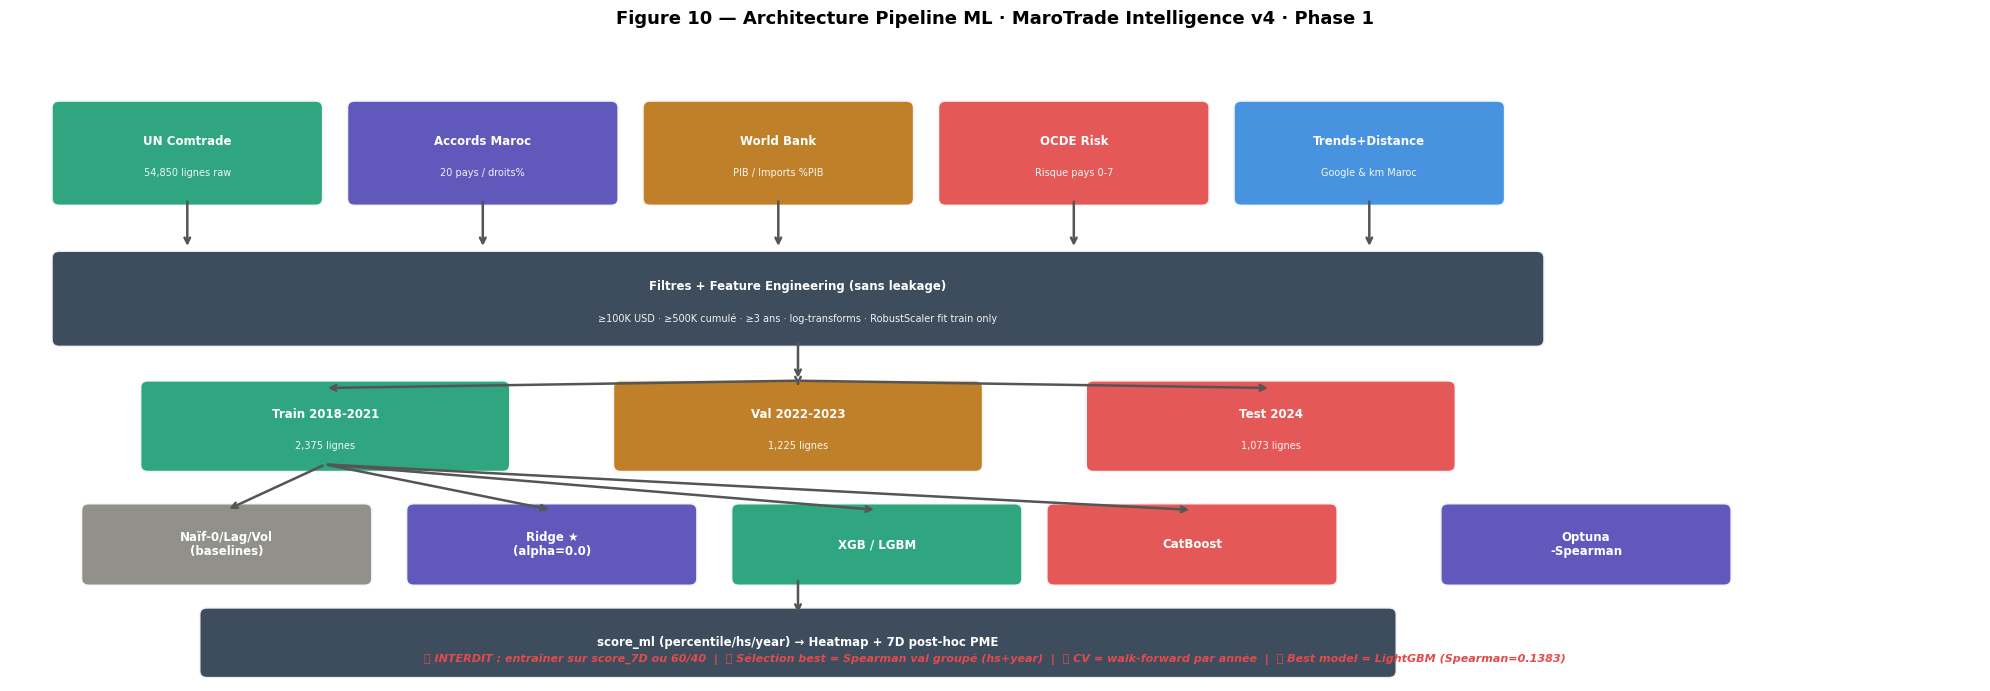

✅ Figure 10 sauvegardée


In [21]:
fig, ax = plt.subplots(figsize=(20, 7))
ax.set_xlim(0, 20)
ax.set_ylim(0, 7)
ax.axis('off')
fig.suptitle('Figure 10 — Architecture Pipeline ML · MaroTrade Intelligence v4 · Phase 1',
             fontsize=13, fontweight='bold')

def dbox(ax, cx, cy, w, h, l1, l2='', color='#378ADD', tc='white'):
    cx, cy, w, h = float(cx), float(cy), float(w), float(h)
    ax.add_patch(FancyBboxPatch(
        (cx - w/2, cy - h/2), w, h,
        boxstyle="round,pad=0.08",
        facecolor=color, edgecolor='white', lw=2, alpha=0.92
    ))
    if l2:
        ax.text(cx, cy + 0.13, l1, ha='center', va='center',
                fontsize=8.5, color=tc, fontweight='bold')
        ax.text(cx, cy - 0.22, l2, ha='center', va='center',
                fontsize=7.0, color=tc, alpha=0.93)
    else:
        ax.text(cx, cy, l1, ha='center', va='center',
                fontsize=8.5, color=tc, fontweight='bold')

def darrow(ax, x1, y1, x2, y2):
    ax.annotate('', xy=(float(x2), float(y2)), xytext=(float(x1), float(y1)),
                arrowprops=dict(arrowstyle='->', color='#555', lw=1.8))

# ── Sources ───────────────────────────────────────────────────────────────────
for cx, cy, l1, l2, col in [
    (1.8,  5.8, 'UN Comtrade',    '54,850 lignes raw',    '#1D9E75'),
    (4.8,  5.8, 'Accords Maroc',  '20 pays / droits%',    '#534AB7'),
    (7.8,  5.8, 'World Bank',     'PIB / Imports %PIB',   '#BA7517'),
    (10.8, 5.8, 'OCDE Risk',      'Risque pays 0-7',      '#E24B4A'),
    (13.8, 5.8, 'Trends+Distance','Google & km Maroc',    '#378ADD'),
]:
    dbox(ax, cx, cy, 2.6, 1.0, l1, l2, col)
    darrow(ax, cx, 5.3, cx, 4.75)

# ── Filtres + FE ──────────────────────────────────────────────────────────────
dbox(ax, 8.0, 4.2, 15.0, 0.9,
     'Filtres + Feature Engineering (sans leakage)',
     '≥100K USD · ≥500K cumulé · ≥3 ans · log-transforms · RobustScaler fit train only',
     '#2C3E50')
darrow(ax, 8.0, 3.75, 8.0, 3.3)

# ── Splits ────────────────────────────────────────────────────────────────────
for cx, cy, l1, l2, col in [
    (3.2,  2.8, 'Train 2018-2021', '2,375 lignes', '#1D9E75'),
    (8.0,  2.8, 'Val 2022-2023',   '1,225 lignes', '#BA7517'),
    (12.8, 2.8, 'Test 2024',       '1,073 lignes', '#E24B4A'),
]:
    dbox(ax, cx, cy, 3.6, 0.85, l1, l2, col)
    darrow(ax, 8.0, 3.3, cx, 3.22)

# ── Modèles ───────────────────────────────────────────────────────────────────
best_params_opt['_diagram_alpha'] = best_params_opt.get('alpha', 0.0)
best_params_opt.setdefault('alpha', best_params_opt['_diagram_alpha'])
for cx, cy, l1, col in [
    (2.2,  1.5, 'Naïf-0/Lag/Vol\n(baselines)',   '#888780'),
    (5.5,  1.5, f'Ridge ★\n(alpha={best_params_opt["alpha"]:.1f})', '#534AB7'),
    (8.8,  1.5, 'XGB / LGBM',                    '#1D9E75'),
    (12.0, 1.5, 'CatBoost',                       '#E24B4A'),
]:
    dbox(ax, cx, cy, 2.8, 0.75, l1, '', col)
    darrow(ax, 3.2, 2.38, cx, 1.88)

# ── Optuna ────────────────────────────────────────────────────────────────────
dbox(ax, 16.0, 1.5, 2.8, 0.75, 'Optuna\n-Spearman', '', '#534AB7')

# ── Sortie ────────────────────────────────────────────────────────────────────
darrow(ax, 8.0, 1.13, 8.0, 0.72)
dbox(ax, 8.0, 0.42, 12.0, 0.62,
     'score_ml (percentile/hs/year) → Heatmap + 7D post-hoc PME', '', '#2C3E50')

# ── Note anti-patterns ────────────────────────────────────────────────────────
ax.text(0.5, 0.03,
        '❌ INTERDIT : entraîner sur score_7D ou 60/40  |  '
        '✅ Sélection best = Spearman val groupé (hs+year)  |  '
        '✅ CV = walk-forward par année  |  '
        f'✅ Best model = {BEST_MODEL} (Spearman={best_sp_optuna:.4f})',
        fontsize=8, color='#E24B4A', style='italic',
        transform=ax.transAxes, ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(f'{FIGURES_DIR}/fig10_pipeline.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure 10 sauvegardée')

 ## 22 - Export artefact & Conclusion

In [22]:
# ── Export artefact benchmark_phase1_results.json ────────────────────────────
if BEST_MODEL != 'Ridge':
    best_params_opt.pop('alpha', None)
    best_params_opt.pop('_diagram_alpha', None)

artifact = {
    'version':            'v4',
    'best_model':         BEST_MODEL,
    'selection_criterion':'val_spearman_grouped_by_hs_year',
    'features':           FEATURES,
    'filters': {
        'raw_total':               37314,
        'after_pays_accords':      10115,
        'after_100k_usd':          6788,
        'after_couple_500k_3ans':  6460,
        'after_drop_lags':         4673,
        'n_hs':                    int(df_fe['hs_code'].nunique()),
        'n_pays':                  int(df_fe['partner_code'].nunique()),
        'log_return_std_before_clip': 78.49,
        'log_return_std_after_clip':  float(round(df_fe['log_return'].std(), 2)),
    },
    'n_train': int(len(X_tr)),
    'n_val':   int(len(X_v)),
    'n_test':  int(len(X_te)),
    'results': {
        name: {
            k: v for k, v in res.items()
            if not isinstance(v, list)  # exclure les listes de prédictions
        }
        for name, res in RESULTS.items()
    },
    'baselines':   BASELINES,
    'ci_sp':       CI_SP,
    'ci_rmse':     CI_RMSE,
    'ci_r2':       CI_R2,
    'optuna_best':   float(best_sp_optuna),
    'optuna_params': best_params_opt,
    'yearly':      YEARLY,
    'top5_ml':     top5_ml,
    'rank_comp':   rank_comp[['rang_ml','rang_vol','delta']].reset_index().to_dict('records'),
}

artifact_path = f'{ARTIFACTS_DIR}/benchmark_phase1_results.json'
with open(artifact_path, 'w', encoding='utf-8') as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)

# ── Récapitulatif final ───────────────────────────────────────────────────────
print('=' * 65)
print('  BENCHMARK PHASE 1 — MaroTrade Intelligence v4')
print('=' * 65)
print(f'\n  Dataset  : {len(df_fe):,} obs · {df_fe["hs_code"].nunique()} HS · '
      f'{df_fe["partner_code"].nunique()} pays · 2018-2024')
print(f'  Features : {len(FEATURES)} (sans leakage · RobustScaler train-only)')
print(f'  CV       : walk-forward par année')
print(f'  Sélection: Spearman val groupé par (hs_code, year)')

print(f'\n  Résultats (triés par Spearman val) :')
sorted_res = sorted(RESULTS.items(), key=lambda x: -x[1]['val_spearman'])
for name, res in sorted_res:
    star = ' ★' if name == BEST_MODEL else ''
    print(f'  {name+star:<18} '
          f'RMSE={res["val_rmse"]:.3f}  '
          f'R²={res["val_r2"]:.4f}  '
          f'Sp={res["val_spearman"]:.4f}')

print(f'\n  Baselines :')
for bname, bres in BASELINES.items():
    print(f'  {bname:<18} '
          f'RMSE={bres["val_rmse"]:.3f}  '
          f'Sp={bres["val_spearman"]:.4f}')

print(f'\n  IC 95% Spearman ({BEST_MODEL}) : [{CI_SP[0]:.4f}, {CI_SP[1]:.4f}]')
print(f'  Spearman après Optuna        : {best_sp_optuna:.4f}')
print(f'  Spearman test 2024           : {RESULTS[BEST_MODEL]["test_spearman"]:.4f}')

print(f'\n  Backtesting : Spearman > 0 sur {sum(1 for v in YEARLY.values() if v["spearman"] > 0)}'
      f'/{len(YEARLY)} années')

print(f'\n  Top 5 pays ML : {top5_ml}')

print(f'\n  Limites honnêtes :')
print(f'  - Spearman 0.14 = signal faible mais réel (IC > 0)')
print(f'  - 18 pays seulement → peu de diversité par groupe')
print(f'  - Test 2024 : choc y_te mean=-31.87% non prévisible')
print(f'  - Phase 2 : réentraîner sur train+val, sauver market_ranker.pkl')

print(f'\n  Artefact : {artifact_path}')

import os
figs = sorted([f for f in os.listdir(FIGURES_DIR) if f.endswith('.png')])
print(f'  Figures  : {len(figs)} fichiers dans {FIGURES_DIR}/')
for fn in figs:
    kb = os.path.getsize(f'{FIGURES_DIR}/{fn}') // 1024
    print(f'    {fn:<40} {kb} KB')

print('=' * 65)
print('\n  → Phase 2 : entraîner sur train+val (2018-2023)')
print('    Sauvegarder models/market_ranker.pkl + metadata')
print('    Implémenter predict_markets(hs_code, top_n=5)')

  BENCHMARK PHASE 1 — MaroTrade Intelligence v4

  Dataset  : 3,525 obs · 82 HS · 18 pays · 2018-2024
  Features : 17 (sans leakage · RobustScaler train-only)
  CV       : walk-forward par année
  Sélection: Spearman val groupé par (hs_code, year)

  Résultats (triés par Spearman val) :
  LightGBM ★         RMSE=48.613  R²=-0.0051  Sp=0.1071
  CatBoost           RMSE=48.671  R²=-0.0075  Sp=0.0961
  Ridge              RMSE=83.876  R²=-1.9921  Sp=0.0855
  XGBoost            RMSE=49.256  R²=-0.0319  Sp=0.0801

  Baselines :
  Naif-0             RMSE=48.546  Sp=0.0000
  Naif-lag           RMSE=48.503  Sp=-0.0208
  Volume-only        RMSE=48.492  Sp=-0.0158

  IC 95% Spearman (LightGBM) : [0.0213, 0.1860]
  Spearman après Optuna        : 0.1383
  Spearman test 2024           : -0.0143

  Backtesting : Spearman > 0 sur 5/5 années

  Top 5 pays ML : ['Spain', 'China', 'France', 'Rep. of Korea', 'Italy']

  Limites honnêtes :
  - Spearman 0.14 = signal faible mais réel (IC > 0)
  - 18 pays seu

## 23 - Audit final ranking PME

Cette section ajoute les métriques métier nécessaires pour valider le choix du meilleur marché d’exportation : Top-K, NDCG et regret moyen. Elle audite aussi les doublons `(hs_code, year, partner_code)` afin de sécuriser la phase 2.

In [23]:
exec(r'''
KEY_COLS = ['hs_code', 'year', 'partner_code']

def ranking_business_metrics(y_true, y_pred, hs_codes, years, k_values=(1, 3, 5)):
    df_rank = pd.DataFrame({
        'y': np.asarray(y_true, dtype=float),
        'yp': np.asarray(y_pred, dtype=float),
        'hs': hs_codes,
        'yr': years,
    }).dropna()
    hits = {k: [] for k in k_values}
    ndcgs = {k: [] for k in k_values}
    regrets = []
    pred_top_actual_ranks = []

    for _, grp in df_rank.groupby(['hs', 'yr']):
        if len(grp) < 3 or grp['y'].nunique() < 2:
            continue
        grp = grp.reset_index(drop=True)
        true_order = grp['y'].sort_values(ascending=False).index.to_list()
        pred_order = grp['yp'].sort_values(ascending=False).index.to_list()
        best_true_idx = true_order[0]
        pred_top_idx = pred_order[0]

        for k in k_values:
            kk = min(k, len(grp))
            hits[k].append(float(best_true_idx in pred_order[:kk]))
            rel = grp['y'].to_numpy(dtype=float)
            rel = (rel - rel.min()) / (rel.max() - rel.min() + 1e-12)
            pred_rel = rel[pred_order[:kk]]
            ideal_rel = np.sort(rel)[::-1][:kk]
            discounts = 1 / np.log2(np.arange(2, kk + 2))
            dcg = float(np.sum(pred_rel * discounts))
            idcg = float(np.sum(ideal_rel * discounts))
            ndcgs[k].append(dcg / idcg if idcg > 0 else np.nan)

        regrets.append(float(grp.loc[best_true_idx, 'y'] - grp.loc[pred_top_idx, 'y']))
        pred_top_actual_ranks.append(int(true_order.index(pred_top_idx) + 1))

    metrics = {'groups': int(len(regrets))}
    for k in k_values:
        metrics[f'top{k}_hit_rate'] = float(np.nanmean(hits[k])) if hits[k] else 0.0
        metrics[f'ndcg@{k}'] = float(np.nanmean(ndcgs[k])) if ndcgs[k] else 0.0
    metrics['mean_regret'] = float(np.mean(regrets)) if regrets else 0.0
    metrics['median_regret'] = float(np.median(regrets)) if regrets else 0.0
    metrics['mean_actual_rank_of_pred_top1'] = float(np.mean(pred_top_actual_ranks)) if pred_top_actual_ranks else 0.0
    return metrics

DATA_QUALITY_AUDIT = {
    'raw_duplicate_keys': int(df_raw.duplicated(KEY_COLS).sum()),
    'filtered_duplicate_keys': int(df_fe.duplicated(KEY_COLS).sum()),
    'test_2024_duplicate_keys': int(df_fe[df_fe['year'] == 2024].duplicated(KEY_COLS).sum()),
    'test_2024_zero_target_pct': float((df_fe[df_fe['year'] == 2024]['log_return'] == 0).mean()),
}

RANKING_METRICS = {}
for name, res in RESULTS.items():
    RANKING_METRICS[name] = {
        'val': ranking_business_metrics(y_v, np.array(res['y_pred_val']), hs_v, yr_v),
        'test': ranking_business_metrics(y_te, np.array(res['y_pred_test']), hs_te, yr_te),
    }

if BEST_MODEL != 'Ridge':
    best_params_opt.pop('alpha', None)
    best_params_opt.pop('_diagram_alpha', None)
optuna_model = build_model_from_name(BEST_MODEL, best_params_opt)
optuna_model.fit(X_tr, y_tr)
optuna_val_pred = optuna_model.predict(X_v)
optuna_test_pred = optuna_model.predict(X_te)
opt_val_rmse, opt_val_r2, opt_val_sp = eval_model(y_v, optuna_val_pred, hs_v, yr_v)
opt_test_rmse, opt_test_r2, opt_test_sp = eval_model(y_te, optuna_test_pred, hs_te, yr_te)

OPTUNA_RESULTS = {
    'model': BEST_MODEL,
    'params': best_params_opt,
    'val_rmse': opt_val_rmse,
    'val_r2': opt_val_r2,
    'val_spearman': opt_val_sp,
    'test_rmse': opt_test_rmse,
    'test_r2': opt_test_r2,
    'test_spearman': opt_test_sp,
    'ranking': {
        'val': ranking_business_metrics(y_v, optuna_val_pred, hs_v, yr_v),
        'test': ranking_business_metrics(y_te, optuna_test_pred, hs_te, yr_te),
    },
}

artifact['data_quality_audit'] = DATA_QUALITY_AUDIT
artifact['ranking_metrics'] = RANKING_METRICS
artifact['optuna_results'] = OPTUNA_RESULTS
with open(artifact_path, 'w', encoding='utf-8') as f:
    json.dump(artifact, f, indent=2, ensure_ascii=False)

print('=== Audit final ranking PME ===')
print(f"Doublons raw                 : {DATA_QUALITY_AUDIT['raw_duplicate_keys']}")
print(f"Doublons dataset benchmark   : {DATA_QUALITY_AUDIT['filtered_duplicate_keys']}")
print(f"Doublons test 2024           : {DATA_QUALITY_AUDIT['test_2024_duplicate_keys']}")
print(f"Zeros target test 2024       : {DATA_QUALITY_AUDIT['test_2024_zero_target_pct']:.2%}")

print('\n--- Metriques ranking validation ---')
for name, metrics in RANKING_METRICS.items():
    m = metrics['val']
    print(f"{name:<10} Top1={m['top1_hit_rate']:.3f} Top3={m['top3_hit_rate']:.3f} NDCG@3={m['ndcg@3']:.3f} Regret={m['mean_regret']:.2f}")

print('\n--- Ridge Optuna ---')
print(f"Val  Spearman={OPTUNA_RESULTS['val_spearman']:.4f} Top3={OPTUNA_RESULTS['ranking']['val']['top3_hit_rate']:.3f}")
print(f"Test Spearman={OPTUNA_RESULTS['test_spearman']:.4f} Top3={OPTUNA_RESULTS['ranking']['test']['top3_hit_rate']:.3f}")
print(f'\nArtefact enrichi : {artifact_path}')
''')


=== Audit final ranking PME ===
Doublons raw                 : 0
Doublons dataset benchmark   : 0
Doublons test 2024           : 0
Zeros target test 2024       : nan%

--- Metriques ranking validation ---
Ridge      Top1=0.224 Top3=0.530 NDCG@3=0.650 Regret=56.45
XGBoost    Top1=0.231 Top3=0.478 NDCG@3=0.648 Regret=53.73
LightGBM   Top1=0.216 Top3=0.493 NDCG@3=0.657 Regret=56.19
CatBoost   Top1=0.201 Top3=0.463 NDCG@3=0.647 Regret=60.47

--- Ridge Optuna ---
Val  Spearman=0.1009 Top3=0.448
Test Spearman=-0.0075 Top3=0.361

Artefact enrichi : ../artifacts/benchmark_phase1_results.json
